# Notebook 03 — Event-Conditioned Reliability Analysis

**Thesis Results** | **Input** `data/2_events.csv` | **Outputs** `data/3_results.csv` and `data/3_odds_ratios.csv`

## Purpose

| Research question | Notebook deliverable |
|---|---|
| RQ2 | Eight descriptive PDR profiles followed by one common ΔPDR and synchronized block-bootstrap comparison |
| RQ3 | Adjusted logistic models for loss occurrence and burst-loss occurrence using predictors with adequate outcome support |

## Analysis sequence

1. Plot the PDR profile underlying each event definition.
2. Compare the locked event conditions using ΔPDR.
3. Estimate synchronized 1-day block-bootstrap confidence intervals (primary design).
4. Report which RQ2 contrasts are supported and verify them with 3-day, 7-day, and 14-day blocks.
5. Apply a separate data-adequacy check before multivariable modeling.
6. Fit the loss-occurrence and burst-occurrence models with the eligible events and device fixed effects.

All analyses use valid reconstructed intervals in `df_link`, which excludes confirmed infrastructure-outage intervals and undefined counter boundaries.


## 0 · Imports & Load

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings('ignore', category=FutureWarning)

DATA_DIR = Path('../data')
INPUT_FILE = DATA_DIR / '2_events.csv'

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        f'{INPUT_FILE} was not found. Run the reconstruction and event '
        'notebooks before this statistical analysis.'
    )

df = pd.read_csv(INPUT_FILE)
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values(['device_id', 'time']).reset_index(drop=True)

EXPECTED_DEVICES = ['ED0', 'ED1', 'ED2', 'ED3', 'ED4', 'ED5']
REQUIRED_INPUT_COLUMNS = [
    'device_id', 'time', 'is_outage', 'tx_loss', 'co2', 'pm25',
    'temperature', 'humidity', 'esp', 'e1_co2_tier',
    'e3_office_hours', 'e4_pm25_tier', 'e5_temp_tier',
    'e6_humidity_tier', 'e7_sf', 'e8_esp_tier',
]
missing_columns = [c for c in REQUIRED_INPUT_COLUMNS if c not in df.columns]
if missing_columns:
    raise KeyError(f'Missing required input columns: {missing_columns}')

assert sorted(df['device_id'].dropna().unique()) == EXPECTED_DEVICES, (
    f'Subset detected: {sorted(df["device_id"].dropna().unique())}. '
    'Rerun the upstream notebooks on the full six-device dataset.'
)
assert len(df) >= 2_600_000, (
    f'Only {len(df):,} rows were loaded. The full campaign is required.'
)

# Locked E2 definition
# The rate is calculated between consecutive received observations from
# the same device. Pairs separated by more than three minutes are not
# classified.
elapsed_min = (
    df.groupby('device_id', sort=False)['time']
    .diff()
    .dt.total_seconds()
    .div(60.0)
)
co2_delta = df.groupby('device_id', sort=False)['co2'].diff()
co2_rate = co2_delta.div(elapsed_min)
valid_e2 = (
    elapsed_min.gt(0)
    & elapsed_min.le(3)
    & co2_rate.notna()
    & np.isfinite(co2_rate)
)

df['co2_rate_ppm_per_min'] = co2_rate.where(valid_e2)
df['e2_co2_transition'] = pd.Series(pd.NA, index=df.index, dtype='Int8')
df.loc[valid_e2, 'e2_co2_transition'] = (
    co2_rate.loc[valid_e2].abs().gt(15)
).astype('int8')

# Locked E8 definition
df['e8_esp_tier'] = pd.cut(
    pd.to_numeric(df['esp'], errors='coerce'),
    bins=[-np.inf, -130, -100, np.inf],
    labels=['poor', 'moderate', 'strong'],
    right=False,
)

tx_loss_numeric = pd.to_numeric(df['tx_loss'], errors='coerce')
valid_reconstruction = tx_loss_numeric.notna()
non_outage = ~df['is_outage'].astype(bool)

# A row is eligible only when its reconstructed loss count is defined and
# it is not attributed to an infrastructure outage.
df_link = df.loc[non_outage & valid_reconstruction].copy().reset_index(drop=True)
df_link['tx_loss'] = pd.to_numeric(df_link['tx_loss'], errors='raise')

n_e2_valid = int(df_link['e2_co2_transition'].notna().sum())
n_e2_active = int(df_link['e2_co2_transition'].eq(1).sum())
e2_share = 100.0 * n_e2_active / n_e2_valid if n_e2_valid else np.nan

print(f'Full dataset                    {len(df):,} rows')
print(f'Valid link-analysis intervals   {len(df_link):,} rows')
print(f'Outage rows excluded            {int((~non_outage).sum()):,}')
print(
    f'Undefined counter boundaries    '
    f'{int((non_outage & ~valid_reconstruction).sum()):,}'
)
print(f'Devices                         {sorted(df_link["device_id"].unique())}')
print(f'Campaign                        {df["time"].min().date()} to {df["time"].max().date()}')
print(f'Valid E2 pairs                  {n_e2_valid:,}')
print(f'Rapid E2 transitions            {n_e2_active:,} ({e2_share:.3f}%)')
print('E8 thresholds                   -130 dBm and -100 dBm')


Full dataset                    2,634,930 rows
Valid link-analysis intervals   2,634,454 rows
Outage rows excluded            476
Undefined counter boundaries    0
Devices                         ['ED0', 'ED1', 'ED2', 'ED3', 'ED4', 'ED5']
Campaign                        2024-10-01 to 2025-09-30
Valid E2 pairs                  2,611,385
Rapid E2 transitions            10,062 (0.385%)
E8 thresholds                   -130 dBm and -100 dBm


In [2]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update(
    {
        'font.family': 'serif',
        'font.size': 13,
        'axes.titlesize': 15,
        'axes.labelsize': 15,
        'xtick.labelsize': 13,
        'ytick.labelsize': 13,
        'legend.fontsize': 12,
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': True,
        'axes.axisbelow': True,
        'grid.alpha': 0.25,
        'grid.linestyle': '--',
    }
)

# Colour language fixed to the E1 scheme across every event figure:
# blue = lowest/reference tier, orange = moderate, red = highest/most
# concerning tier. E2 and E3 reuse the same three colours for their own
# two- or three-way splits so the whole chapter reads as one palette.
C = {
    'blue': '#0077BB',
    'orange': '#EE7733',
    'green': '#009988',
    'red': '#CC3311',
    'purple': '#AA3377',
    'navy': '#004488',
    'grey': '#BBBBBB',
    'brown': '#882255',
    'teal': '#44AA99',
    'yellow': '#DDCC77',
}

TOA_MS = {7: 71.9, 8: 133.6, 9: 246.8, 10: 452.6, 11: 987.1, 12: 1810.4}
FIG_DIR = Path('../figures/3')
FIG_DIR.mkdir(parents=True, exist_ok=True)

PDR_LABEL = 'PDR$_{\\mathrm{link}}$ (%)'
EVENT_FIGSIZE = (7.6, 4.8)
LABEL_FONTSIZE = 15   # matches thesis body-text size more closely than 13-14
TICK_FONTSIZE = 13
LEGEND_FONTSIZE = 12


def save_fig(fig, name):
    """Save one 300 dpi PNG. PDF output intentionally dropped."""
    png_path = FIG_DIR / f'{name}.png'
    fig.savefig(png_path)
    print(f'Saved {png_path}')
    plt.show()


def pdr_grp(grp):
    """Pooled link PDR for valid reconstructed intervals."""
    losses = pd.to_numeric(grp['tx_loss'], errors='coerce')
    if losses.isna().any():
        raise ValueError('PDR received an undefined reconstructed loss count.')
    rx = len(losses)
    lost = float(losses.sum())
    denominator = rx + lost
    return 100.0 * rx / denominator if denominator > 0 else np.nan


def burst_rate_grp(grp):
    return 100.0 * pd.to_numeric(grp['tx_loss'], errors='coerce').ge(3).mean()


def event_panel(figsize=EVENT_FIGSIZE):
    """One thesis-width axis for an RQ2 profile."""
    return plt.subplots(figsize=figsize)


def _tier_preserving_limits(values, boundaries, quantile_range):
    """Robust plotting range: 1st/99th percentile computed WITHIN each
    locked tier separately, then combined, so a rare-but-real tier is not
    deleted just because it is a small fraction of the total."""
    q_low, q_high = quantile_range
    tier_id = np.digitize(values.to_numpy(), boundaries, right=True)
    lows, highs = [], []
    for i in range(len(boundaries) + 1):
        tier_values = values[tier_id == i]
        if tier_values.empty:
            continue
        lows.append(float(tier_values.quantile(q_low)))
        highs.append(float(tier_values.quantile(q_high)))
    if not lows:
        raise ValueError('No finite values are available for the PDR profile.')
    lo, hi = min(lows), max(highs)
    if hi <= lo:
        hi = lo + 1.0
    return lo, hi


def _equal_count_bin_ids(x, n_bins, tie_seed=42):
    """Assign n_bins equal-COUNT bin ids to x, with ties broken by
    independent random jitter rather than row order.

    Two failure modes this avoids, both verified on synthetic data before
    use here:
      1. Equal-WIDTH bins starve sparse tails of a peaked distribution
         (e.g. E2's CO2 rate sits near zero almost always), so a handful
         of points anchor a tail bin and the estimated PDR swings wildly
         between adjacent bins.
      2. Naive quantile edges (np.quantile / pd.qcut) collapse when the
         data has heavy exact ties (an integer-resolution sensor produces
         many repeated deltas): requesting 150 bins can silently collapse
         to 8-10 actual bins, each dominated by one repeated value, which
         is WORSE than equal-width, not better.
      Breaking ties by ROW ORDER (pandas' default rank(method='first'))
      would group temporally-adjacent points together, reintroducing the
      very time-correlation (outages, seasonal drift) this profile
      exists to average over. Random-jitter tie-breaking avoids that:
      confirmed on synthetic data with a time-drifting confound unrelated
      to the profiled variable, position-order tie-breaking produced
      roughly double the bin-to-bin noise of jitter tie-breaking.
    """
    n = len(x)
    tie_rng = np.random.default_rng(tie_seed)
    jitter = tie_rng.uniform(-1e-9, 1e-9, n)
    order = np.argsort(x + jitter)
    bin_id = np.empty(n, dtype=int)
    bin_id[order] = np.floor(np.linspace(0, n_bins, n, endpoint=False)).astype(int)
    return bin_id


def pdr_profile(
    ax,
    data,
    col,
    boundaries=None,
    tier_colors=None,
    tier_labels=None,
    xlabel=None,
    color=None,
    log_x=False,
    quantile_range=(0.001, 0.999),
    target_per_bin=8000,
    min_bins_per_tier=15,
    max_bins_per_tier=150,
    min_n=500,
    connect_tiers=True,
):
    """PDR against a continuous event variable, binned equal-count within
    each locked tier separately (so no bin straddles a tier boundary).
    """
    boundaries = sorted(list(boundaries or []))
    values = pd.to_numeric(data[col], errors='coerce')
    finite = values.notna() & np.isfinite(values)
    if log_x:
        finite &= values.gt(0)

    work = data.loc[finite].copy()
    work['_profile_x'] = values.loc[finite].astype(float)
    if work.empty:
        raise ValueError(f'No valid values are available for {col}.')

    lo, hi = _tier_preserving_limits(work['_profile_x'], boundaries, quantile_range)
    work = work.loc[work['_profile_x'].between(lo, hi, inclusive='both')].copy()
    work['_tier_id'] = np.digitize(work['_profile_x'].to_numpy(), boundaries, right=True)

    points = []
    for tier_id in range(len(boundaries) + 1):
        tier_data = work.loc[work['_tier_id'].eq(tier_id)]
        if len(tier_data) < min_n:
            continue

        n_bins = int(np.clip(round(len(tier_data) / target_per_bin),
                             min_bins_per_tier, max_bins_per_tier))
        n_bins = min(n_bins, max(1, len(tier_data) // min_n))

        x_arr = tier_data['_profile_x'].to_numpy()
        if n_bins <= 1:
            bin_id = np.zeros(len(tier_data), dtype=int)
        else:
            bin_id = _equal_count_bin_ids(x_arr, n_bins)

        for b in range(bin_id.max() + 1):
            mask = bin_id == b
            n_b = int(mask.sum())
            if n_b < min_n:
                continue
            bin_data = tier_data.loc[mask]
            points.append({
                'x': float(np.median(x_arr[mask])),
                'pdr': pdr_grp(bin_data),
                'n': n_b,
                'tier': tier_id,
            })

    profile = pd.DataFrame(points).sort_values('x').reset_index(drop=True)
    if profile.empty:
        raise ValueError(f'No {col} bins meet the minimum size of {min_n:,} intervals.')

    if tier_colors is not None:
        if len(tier_colors) != len(boundaries) + 1:
            raise ValueError('tier_colors must contain one colour per locked tier.')
        raw_edges = [-np.inf] + boundaries + [np.inf]
        for tier_id, tier_color in enumerate(tier_colors):
            left = max(lo, raw_edges[tier_id])
            right = min(hi, raw_edges[tier_id + 1])
            if left < right:
                ax.axvspan(left, right, color=tier_color, alpha=0.10, zorder=0)

    profile_parts = (
        [profile] if connect_tiers
        else [g for _, g in profile.groupby('tier', sort=True)]
    )
    for part in profile_parts:
        ax.plot(part['x'], part['pdr'], 'o-', color=color or C['navy'],
                linewidth=2.2, markersize=5, zorder=3)

    for boundary in boundaries:
        if lo < boundary < hi:
            ax.axvline(boundary, color='#777777', linestyle='--', linewidth=1.2, zorder=1)

    if log_x:
        ax.set_xscale('log')

    if tier_labels is not None:
        if tier_colors is None or len(tier_labels) != len(tier_colors):
            raise ValueError('tier_labels and tier_colors must describe the same tiers.')
        handles = [mpatches.Patch(color=c, alpha=0.22, label=lab)
                  for c, lab in zip(tier_colors, tier_labels)]
        # legend anchored BELOW the axes, not above
        ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.16),
                 ncol=len(handles), frameon=False, fontsize=LEGEND_FONTSIZE,
                 handlelength=1.2, columnspacing=1.2)

    ax.set_xlabel(xlabel or col, fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_ylabel(PDR_LABEL, fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.tick_params(labelsize=TICK_FONTSIZE)
    ax.set_xlim(lo, hi)
    ax.margins(y=0.08)
    return profile


print('Figure style and profile functions ready (rank+jitter equal-count binning, PNG-only output, bottom legends).')


Figure style and profile functions ready (rank+jitter equal-count binning, PNG-only output, bottom legends).


## 1 · Statistical Framework

The RQ2 analysis separates descriptive profiles from inferential comparisons.

1. **Descriptive profile** — continuous observations are ordered within each locked tier and divided into approximately equal-count bins. Each point uses the observed median measurement on the x axis and pooled link PDR on the y axis. The display normally retains the 1st to 99th percentile within every tier.
2. **Locked contrast** — one predefined comparison is calculated for each event, such as high versus background CO₂ or SF12 versus SF7.
3. **Primary inference** — a synchronized 1-day block bootstrap resamples complete calendar blocks while keeping all devices together, matching the design locked in Chapter 3. The 95% confidence interval uses 10,000 bootstrap ΔPDR estimates.
4. **RQ2 decision rule** — a contrast is statistically supported when its 95% confidence interval excludes zero.
5. **Sensitivity analysis** — the support decision and effect direction are checked with 3-day, 7-day, and 14-day blocks.
6. **RQ3 data adequacy** — statistical support in a single-event contrast does not automatically select a regression predictor. Every modeled level must contain at least 10 burst outcomes, and the predictor must be defined for every modeled interval.

The descriptive curves reveal the shape of each relationship. The locked ΔPDR contrasts answer RQ2. The separate data-adequacy rule prevents RQ3 coefficients from being estimated from structurally missing predictors or only a handful of burst outcomes.


In [3]:
PDR_BOOTSTRAP_REPS = 10000
PRIMARY_BLOCK_DAYS = 1
SENSITIVITY_BLOCK_DAYS = (3, 7, 14)
BOOTSTRAP_RANDOM_STATE = 42


def pdr_compare(
    df_in,
    event_col,
    group1_label,
    group0_label=None,
    n_boot=PDR_BOOTSTRAP_REPS,
    block_days=PRIMARY_BLOCK_DAYS,
    random_state=BOOTSTRAP_RANDOM_STATE,
):
    """
    Compare pooled PDR between two locked event groups with a synchronized
    time-block bootstrap.

    Each resampled block contains all devices. This preserves temporal loss
    clustering and cross-device exposure to shared conditions.
    """
    active_mask = df_in[event_col].eq(group1_label)
    if group0_label is None:
        reference_mask = (~active_mask) & df_in[event_col].notna()
        reference_name = f'not {group1_label}'
    else:
        reference_mask = df_in[event_col].eq(group0_label)
        reference_name = group0_label

    if (active_mask & reference_mask).any():
        raise ValueError('Active and reference groups overlap.')

    n_active_raw = int(active_mask.sum())
    n_reference_raw = int(reference_mask.sum())
    if n_active_raw == 0 or n_reference_raw == 0:
        raise ValueError(
            f'Empty comparison group for {event_col}. '
            f'Active={n_active_raw:,}, reference={n_reference_raw:,}.'
        )

    campaign_start = df_in['time'].min().floor('D')
    seconds_per_block = block_days * 24 * 60 * 60
    block_ids_full = (
        (df_in['time'] - campaign_start).dt.total_seconds()
        // seconds_per_block
    ).astype(int)
    all_blocks = np.sort(block_ids_full.unique())

    selected_mask = active_mask | reference_mask
    work = df_in.loc[selected_mask, ['time', 'tx_loss']].copy()
    work['block_id'] = block_ids_full.loc[work.index].to_numpy()

    active_sel = active_mask.loc[work.index].astype(np.int8).to_numpy()
    reference_sel = reference_mask.loc[work.index].astype(np.int8).to_numpy()
    loss_series = pd.to_numeric(work['tx_loss'], errors='coerce')
    if loss_series.isna().any():
        raise ValueError(
            f'{event_col} contains undefined reconstructed loss counts.'
        )
    losses = loss_series.to_numpy(dtype=float)

    work['rx_active'] = active_sel
    work['loss_active'] = losses * active_sel
    work['rx_reference'] = reference_sel
    work['loss_reference'] = losses * reference_sel

    count_cols = [
        'rx_active',
        'loss_active',
        'rx_reference',
        'loss_reference',
    ]
    block_totals = (
        work.groupby('block_id', sort=True)[count_cols]
        .sum()
        .reindex(all_blocks, fill_value=0.0)
    )

    observed = block_totals.sum(axis=0)
    rx_active = int(observed['rx_active'])
    loss_active = int(round(observed['loss_active']))
    rx_reference = int(observed['rx_reference'])
    loss_reference = int(round(observed['loss_reference']))

    def _pdr(rx, lost):
        denominator = rx + lost
        return 100.0 * rx / denominator if denominator > 0 else np.nan

    pdr_active = _pdr(rx_active, loss_active)
    pdr_reference = _pdr(rx_reference, loss_reference)
    delta_observed = pdr_active - pdr_reference

    values = block_totals.to_numpy(dtype=float)
    n_blocks = len(values)
    if n_blocks < 8:
        raise ValueError(
            f'Only {n_blocks} blocks are available for {event_col}. '
            'Use a shorter block length.'
        )

    rng = np.random.default_rng(random_state)
    sampled_idx = rng.integers(0, n_blocks, size=(n_boot, n_blocks))
    sampled_totals = values[sampled_idx].sum(axis=1)

    rx_a, loss_a = sampled_totals[:, 0], sampled_totals[:, 1]
    rx_r, loss_r = sampled_totals[:, 2], sampled_totals[:, 3]
    denominator_a = rx_a + loss_a
    denominator_r = rx_r + loss_r
    valid = (denominator_a > 0) & (denominator_r > 0)

    boot_deltas = (
        100.0 * rx_a[valid] / denominator_a[valid]
        - 100.0 * rx_r[valid] / denominator_r[valid]
    )

    minimum_valid = max(100, int(np.ceil(0.5 * n_boot)))
    if len(boot_deltas) < minimum_valid:
        raise RuntimeError(
            f'Only {len(boot_deltas):,} of {n_boot:,} bootstrap samples '
            f'contained both groups for {event_col}.'
        )

    ci_low, ci_high = np.percentile(boot_deltas, [2.5, 97.5])
    supported = bool((ci_high < 0) or (ci_low > 0))
    inference = (
        'lower PDR'
        if ci_high < 0
        else ('higher PDR' if ci_low > 0 else 'inconclusive')
    )

    return {
        'group1': group1_label,
        'n1': rx_active,
        'pdr1': pdr_active,
        'group0': reference_name,
        'n0': rx_reference,
        'pdr0': pdr_reference,
        'diff_pp': delta_observed,
        'ci_low_pp': float(ci_low),
        'ci_high_pp': float(ci_high),
        'statistically_supported': supported,
        'inference': inference,
        'n_blocks': n_blocks,
        'block_days': block_days,
        'n_boot': int(len(boot_deltas)),
    }


def print_comparison(result, title=''):
    support_text = (
        'statistically supported'
        if result['statistically_supported']
        else 'inconclusive because the CI includes zero'
    )
    print(title)
    print(
        f'  {str(result["group1"]):>20}  '
        f'{result["pdr1"]:.2f}%  n={result["n1"]:,}'
    )
    print(
        f'  {str(result["group0"]):>20}  '
        f'{result["pdr0"]:.2f}%  n={result["n0"]:,}'
    )
    print(f'  Difference             {result["diff_pp"]:+.2f} pp')
    print(
        f'  95% block-bootstrap CI '
        f'[{result["ci_low_pp"]:+.2f}, {result["ci_high_pp"]:+.2f}] pp'
    )
    print(f'  Inference              {result["inference"]}, {support_text}')
    print(
        f'  Bootstrap              {result["n_boot"]:,} samples of '
        f'{result["n_blocks"]} synchronized {result["block_days"]}-day blocks'
    )
    print()


print('Statistical framework ready.')
print(
    f'Primary design  {PDR_BOOTSTRAP_REPS:,} synchronized '
    f'{PRIMARY_BLOCK_DAYS}-day block samples'
)
print(
    'Sensitivity     '
    + ', '.join(f'{days}-day blocks' for days in SENSITIVITY_BLOCK_DAYS)
)


Statistical framework ready.
Primary design  10,000 synchronized 1-day block samples
Sensitivity     3-day blocks, 7-day blocks, 14-day blocks


## 2 · CO₂ Tier

**Event E1** tests how link PDR varies across the locked background, moderate, and high CO₂ concentration tiers.


In [4]:
print('=' * 60)
print('CO2 TIER (§7.4)')
print('=' * 60)

occupancy_results = {}

# E1: CO2 tier — three-way comparison
print('\nE1: CO2 Tier PDR')
co2_pdrs = {}
for tier in ['background', 'moderate', 'high']:
    g = df_link[df_link['e1_co2_tier'] == tier]
    rx = len(g)
    lost = int(g['tx_loss'].sum())
    pdr = rx / (rx + lost) * 100
    co2_pdrs[tier] = pdr
    print(f'    {tier:<12}: {pdr:.2f}%  (n={rx:,})')

# key comparison: high vs background
print('\nE1: High vs Background CO2 (key comparison)')
r = pdr_compare(df_link, 'e1_co2_tier', 'high', 'background')
print_comparison(r, 'High CO2 vs Background')
occupancy_results['E1_high_vs_bg'] = r

# moderate vs background
r = pdr_compare(df_link, 'e1_co2_tier', 'moderate', 'background')
print_comparison(r, 'Moderate CO2 vs Background')
occupancy_results['E1_mod_vs_bg'] = r

CO2 TIER (§7.4)

E1: CO2 Tier PDR
    background  : 98.32%  (n=1,670,651)
    moderate    : 97.59%  (n=742,541)
    high        : 95.07%  (n=221,262)

E1: High vs Background CO2 (key comparison)
High CO2 vs Background
                  high  95.07%  n=221,262
            background  98.32%  n=1,670,651
  Difference             -3.25 pp
  95% block-bootstrap CI [-3.90, -2.62] pp
  Inference              lower PDR, statistically supported
  Bootstrap              10,000 samples of 350 synchronized 1-day blocks

Moderate CO2 vs Background
              moderate  97.59%  n=742,541
            background  98.32%  n=1,670,651
  Difference             -0.74 pp
  95% block-bootstrap CI [-1.03, -0.47] pp
  Inference              lower PDR, statistically supported
  Bootstrap              10,000 samples of 350 synchronized 1-day blocks



Saved ..\figures\3\05_03_a_co2_tier_pdr.png


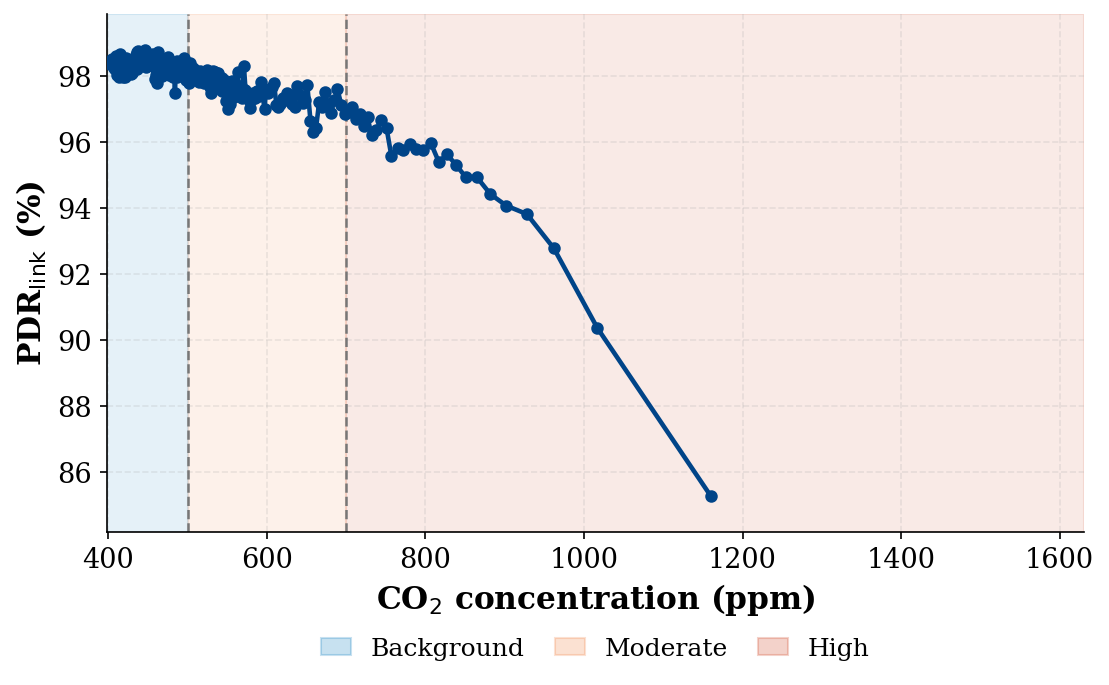

In [5]:
# Fig 05-03-a — CO2 concentration profile (E1)
fig, ax = event_panel()
e1_profile = pdr_profile(
    ax,
    df_link,
    'co2',
    boundaries=[500, 700],
    tier_colors=[C['blue'], C['orange'], C['red']],
    tier_labels=['Background', 'Moderate', 'High'],
    xlabel='CO$_2$ concentration (ppm)',
    color=C['navy'],
)

fig.tight_layout()
save_fig(fig, '05_03_a_co2_tier_pdr')


## 3 · Rapid CO₂ Transition

**Event E2** tests rapid absolute changes in CO₂ concentration. A valid observation pair is classified as a rapid transition when the absolute rate exceeds 15 ppm min⁻¹ and as stable otherwise. Pairs separated by more than three minutes remain unclassified.


In [6]:
print('=' * 60)
print('RAPID CO2 TRANSITION  E2')
print('=' * 60)

print('E2  Rapid transition versus stable')
r = pdr_compare(df_link, 'e2_co2_transition', 1, 0)
print_comparison(r, 'Rapid CO2 transition versus stable')
occupancy_results['E2_transition'] = r


RAPID CO2 TRANSITION  E2
E2  Rapid transition versus stable
Rapid CO2 transition versus stable
                     1  97.76%  n=10,062
                     0  99.02%  n=2,601,323
  Difference             -1.26 pp
  95% block-bootstrap CI [-1.63, -0.90] pp
  Inference              lower PDR, statistically supported
  Bootstrap              10,000 samples of 350 synchronized 1-day blocks



Saved ..\figures\3\05_03_b_co2_transition_pdr.png


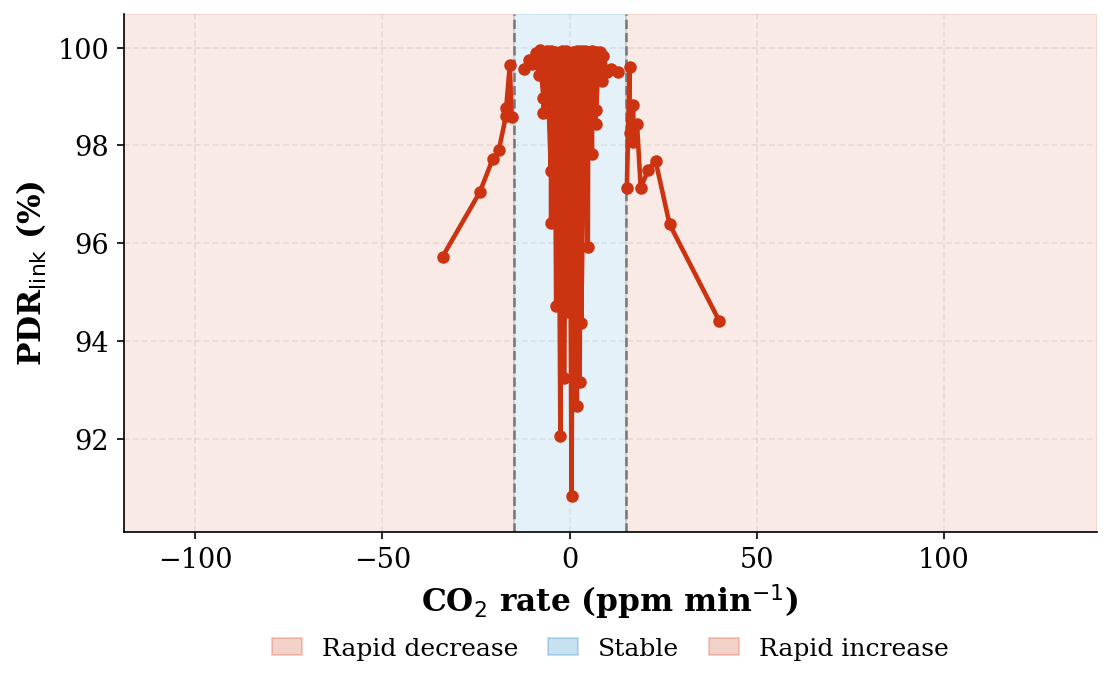

In [7]:
# Fig 05-03-b — CO2 rate profile (E2)
fig, ax = event_panel()
e2_profile = pdr_profile(
    ax,
    df_link,
    'co2_rate_ppm_per_min',
    boundaries=[-15, 15],
    tier_colors=[C['red'], C['blue'], C['red']],
    tier_labels=['Rapid decrease', 'Stable', 'Rapid increase'],
    xlabel='CO$_2$ rate (ppm min$^{-1}$)',
    color=C['red'],
    min_n=500,
    connect_tiers=False,
)

fig.tight_layout()
save_fig(fig, '05_03_b_co2_transition_pdr')


## 4 · Office Hours

**Event E3** compares weekday office hours from 08:00 to 17:59 local time with all off-hour observations.


In [8]:
print('=' * 60)
print('TEMPORAL EVENTS (E3)')
print('=' * 60)

temporal_results = {}

# E3: office hours binary
print('\nE3: Office Hours vs Off-Peak')
r = pdr_compare(df_link, 'e3_office_hours', 1, 0)
print_comparison(r, 'Office hours (1) vs off-peak (0)')
temporal_results['E3_office'] = r

TEMPORAL EVENTS (E3)

E3: Office Hours vs Off-Peak
Office hours (1) vs off-peak (0)
                     1  97.03%  n=768,518
                     0  98.17%  n=1,865,936
  Difference             -1.13 pp
  95% block-bootstrap CI [-1.44, -0.84] pp
  Inference              lower PDR, statistically supported
  Bootstrap              10,000 samples of 350 synchronized 1-day blocks



Saved ..\figures\3\05_03_c_temporal_pdr.png


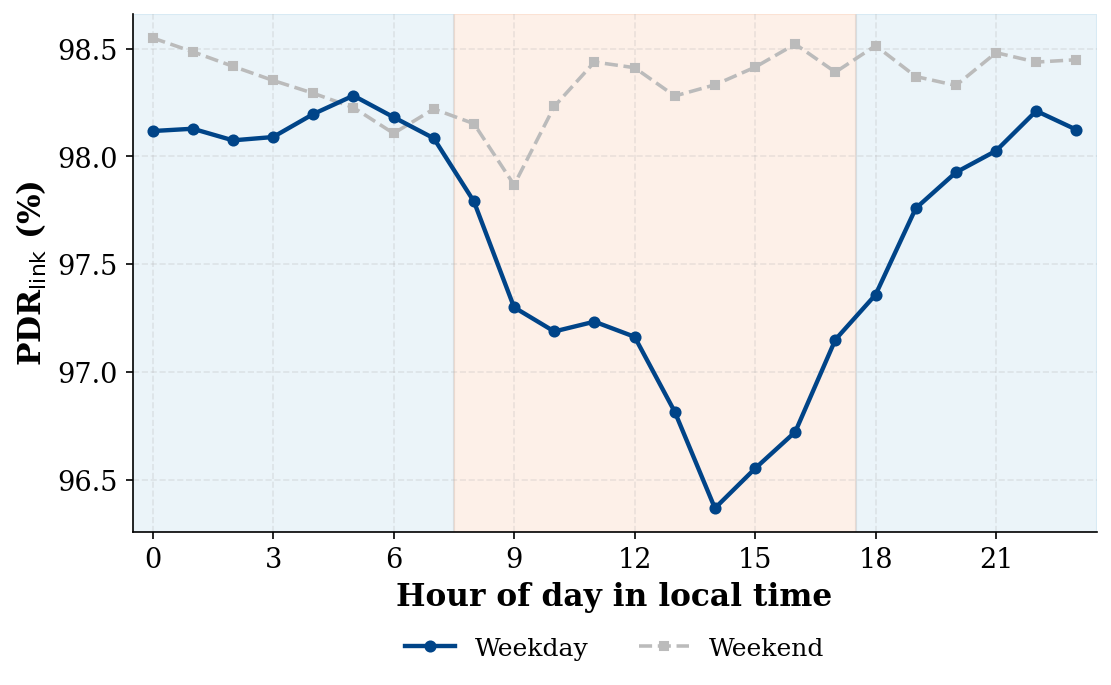

In [9]:
# Fig 05-03-c — PDR by local hour (E3)
local_time = df_link['time'].dt.tz_convert('Europe/Berlin')
local_hour = local_time.dt.hour
is_weekday = local_time.dt.dayofweek.lt(5)
hours = np.arange(24)

weekday_pdr = [
    pdr_grp(df_link.loc[is_weekday & local_hour.eq(hour)])
    for hour in hours
]
weekend_pdr = [
    pdr_grp(df_link.loc[~is_weekday & local_hour.eq(hour)])
    for hour in hours
]

fig, ax = event_panel()
ax.axvspan(-0.5, 7.5, color=C['blue'], alpha=0.08, zorder=0)
ax.axvspan(7.5, 17.5, color=C['orange'], alpha=0.11, zorder=0)
ax.axvspan(17.5, 23.5, color=C['blue'], alpha=0.08, zorder=0)
ax.plot(
    hours,
    weekday_pdr,
    'o-',
    color=C['navy'],
    linewidth=2.1,
    markersize=4.8,
    label='Weekday',
    zorder=3,
)
ax.plot(
    hours,
    weekend_pdr,
    's--',
    color=C['grey'],
    linewidth=1.7,
    markersize=4.2,
    label='Weekend',
    zorder=2,
)
ax.set_xlabel('Hour of day in local time', fontsize=LABEL_FONTSIZE, fontweight='bold')
ax.set_ylabel(PDR_LABEL, fontsize=LABEL_FONTSIZE, fontweight='bold')
ax.set_xticks(np.arange(0, 24, 3))
ax.set_xlim(-0.5, 23.5)
ax.tick_params(labelsize=TICK_FONTSIZE)
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.16),
    ncol=2,
    frameon=False,
    fontsize=LEGEND_FONTSIZE,
)

fig.tight_layout()
save_fig(fig, '05_03_c_temporal_pdr')


## 5 · PM2.5 Tier  *(§7.5.1 — RQ2)*

Event: E4 (PM2.5 tier)

In [10]:
print('=' * 60)
print('AIR QUALITY EVENTS — PM2.5 (§7.5.1)')
print('=' * 60)

air_quality_results = {}

# E4: PM2.5 tier
print('\nE4: PM2.5 Absolute Tier')
for tier in ['clean', 'moderate', 'elevated']:
    g = df_link[df_link['e4_pm25_tier'] == tier]
    if len(g) > 0:
        rx = len(g)
        lost = int(g['tx_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<10}: {pdr:.2f}%  (n={rx:,})')

print('\nE4: Elevated vs Clean (key comparison)')
r = pdr_compare(df_link, 'e4_pm25_tier', 'elevated', 'clean')
print_comparison(r, 'Elevated vs Clean PM2.5')
air_quality_results['E4_elevated_vs_clean'] = r

AIR QUALITY EVENTS — PM2.5 (§7.5.1)

E4: PM2.5 Absolute Tier
    clean     : 98.10%  (n=2,412,352)
    moderate  : 95.74%  (n=215,152)
    elevated  : 78.09%  (n=6,950)

E4: Elevated vs Clean (key comparison)
Elevated vs Clean PM2.5
              elevated  78.09%  n=6,950
                 clean  98.10%  n=2,412,352
  Difference             -20.01 pp
  95% block-bootstrap CI [-27.90, -15.25] pp
  Inference              lower PDR, statistically supported
  Bootstrap              10,000 samples of 350 synchronized 1-day blocks



Saved ..\figures\3\05_03_d_pm25_pdr.png


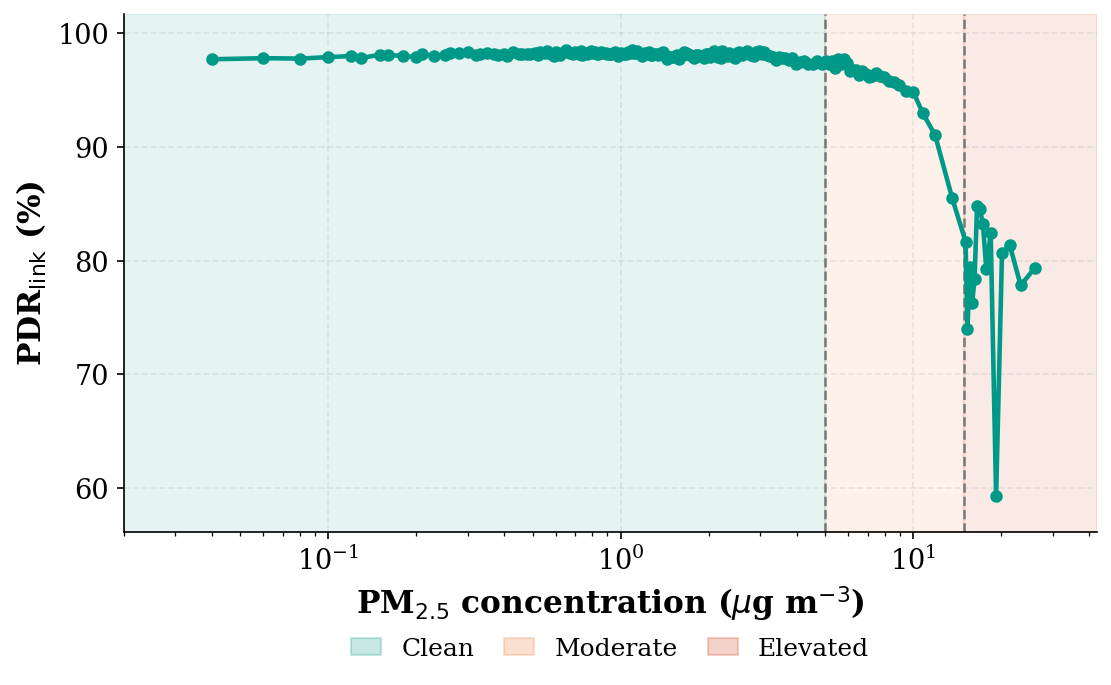

In [11]:
# Fig 05-03-d — PM2.5 concentration profile (E4)
fig, ax = event_panel()
e4_profile = pdr_profile(
    ax,
    df_link,
    'pm25',
    log_x=True,
    boundaries=[5, 15],
    tier_colors=[C['green'], C['orange'], C['red']],
    tier_labels=['Clean', 'Moderate', 'Elevated'],
    xlabel='PM$_{2.5}$ concentration ($\\mu$g m$^{-3}$)',
    color=C['green'],
    min_n=200,
)

fig.tight_layout()
save_fig(fig, '05_03_d_pm25_pdr')


## 6 · Temperature Tier  *(§7.5.2 — RQ2)*

Event: E5 (temperature tier)

In [12]:
print('=' * 60)
print('TEMPERATURE TIER (§7.5.2)')
print('=' * 60)

atm_results = {}

# E5: temperature tier
print('\nE5: Temperature Tier PDR')
for tier in ['cool', 'moderate', 'warm']:
    g = df_link[df_link['e5_temp_tier'] == tier]
    if len(g) > 0:
        rx = len(g)
        lost = int(g['tx_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<10}: {pdr:.2f}%  (n={rx:,})')

print('\nE5: Warm vs Cool (key comparison)')
r = pdr_compare(df_link, 'e5_temp_tier', 'warm', 'cool')
print_comparison(r, 'Warm vs Cool')
atm_results['E5_warm_vs_cool'] = r

TEMPERATURE TIER (§7.5.2)

E5: Temperature Tier PDR
    cool      : 97.30%  (n=876,801)
    moderate  : 97.99%  (n=886,499)
    warm      : 98.21%  (n=871,154)

E5: Warm vs Cool (key comparison)
Warm vs Cool
                  warm  98.21%  n=871,154
                  cool  97.30%  n=876,801
  Difference             +0.91 pp
  95% block-bootstrap CI [+0.49, +1.32] pp
  Inference              higher PDR, statistically supported
  Bootstrap              10,000 samples of 350 synchronized 1-day blocks



Saved ..\figures\3\05_03_e_temperature_pdr.png


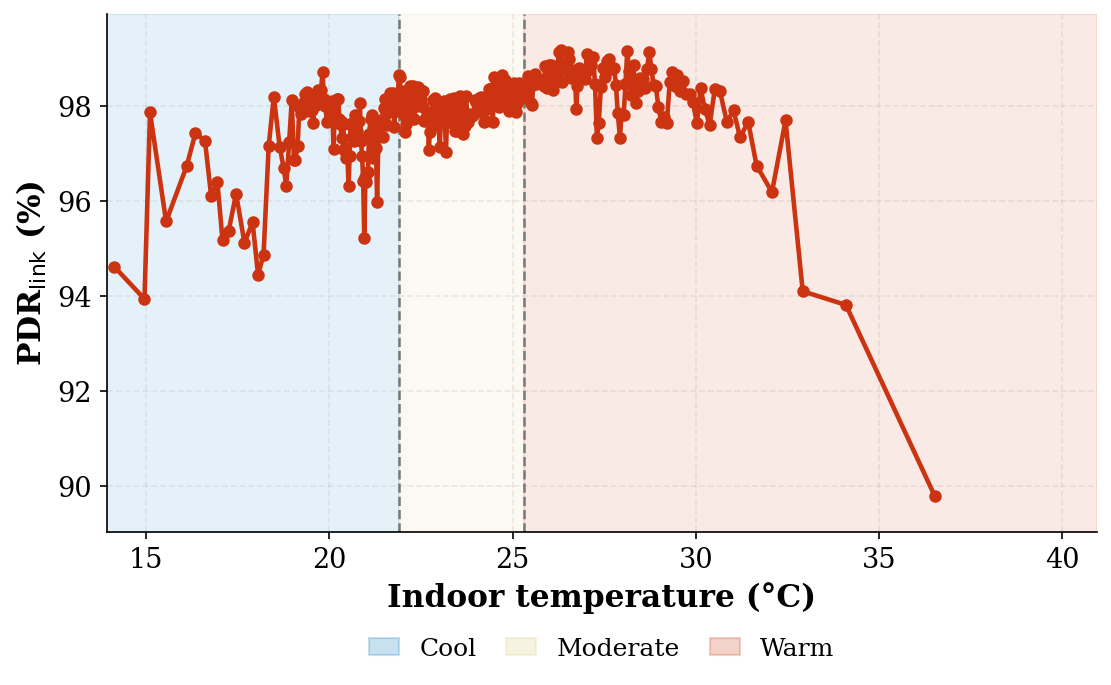

In [13]:
# Fig 05-03-e — Temperature profile (E5)
fig, ax = event_panel()
e5_profile = pdr_profile(
    ax,
    df_link,
    'temperature',
    boundaries=[21.9, 25.3],
    tier_colors=[C['blue'], C['yellow'], C['red']],
    tier_labels=['Cool', 'Moderate', 'Warm'],
    xlabel='Indoor temperature (°C)',
    color=C['red'],
)

fig.tight_layout()
save_fig(fig, '05_03_e_temperature_pdr')


## 7 · Humidity Tier  *(§7.5.2 — RQ2)*

Event: E6 (humidity tier)

In [14]:
print('=' * 60)
print('HUMIDITY TIER (§7.5.2)')
print('=' * 60)

# E6: humidity tier
print('\nE6: Humidity Tier PDR')
for tier in ['dry', 'normal', 'humid']:
    g = df_link[df_link['e6_humidity_tier'] == tier]
    if len(g) > 0:
        rx = len(g)
        lost = int(g['tx_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<10}: {pdr:.2f}%  (n={rx:,})')

print('\nE6: Humid vs Dry (key comparison)')
r = pdr_compare(df_link, 'e6_humidity_tier', 'humid', 'dry')
print_comparison(r, 'Humid vs Dry')
atm_results['E6_humid_vs_dry'] = r

HUMIDITY TIER (§7.5.2)

E6: Humidity Tier PDR
    dry       : 96.90%  (n=387,642)
    normal    : 98.00%  (n=2,246,079)
    humid     : 94.70%  (n=733)

E6: Humid vs Dry (key comparison)
Humid vs Dry
                 humid  94.70%  n=733
                   dry  96.90%  n=387,642
  Difference             -2.20 pp
  95% block-bootstrap CI [-5.01, +3.33] pp
  Inference              inconclusive, inconclusive because the CI includes zero
  Bootstrap              9,818 samples of 350 synchronized 1-day blocks



Saved ..\figures\3\05_03_f_humidity_pdr.png


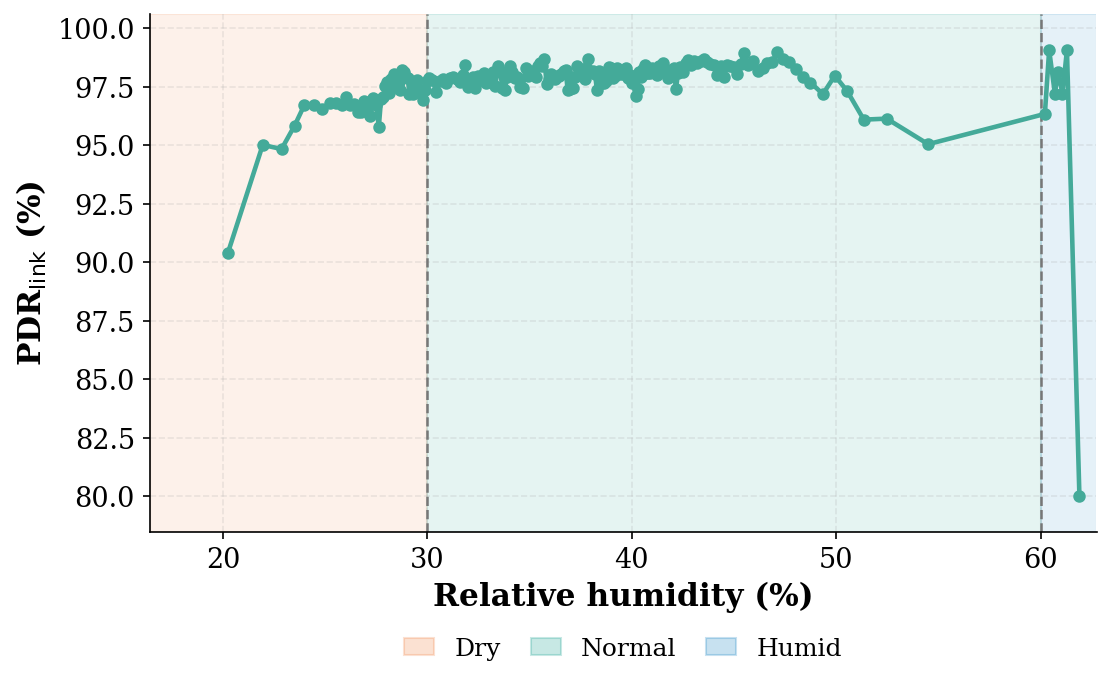

In [15]:
# Fig 05-03-f — Relative-humidity profile (E6)
fig, ax = event_panel()
e6_profile = pdr_profile(
    ax,
    df_link,
    'humidity',
    boundaries=[30, 60],
    tier_colors=[C['orange'], C['green'], C['blue']],
    tier_labels=['Dry', 'Normal', 'Humid'],
    xlabel='Relative humidity (%)',
    color=C['teal'],
    min_n=100,
)

fig.tight_layout()
save_fig(fig, '05_03_f_humidity_pdr')


## 8 · Spreading Factor

**Event E7** evaluates the six exact spreading-factor configurations. Their Time on Air values provide the corresponding airtime ordering.


In [16]:
print('=' * 60)
print('SPREADING FACTOR EVENT (E7)')
print('=' * 60)

TOA_MS = {7: 71.9, 8: 133.6, 9: 246.8, 10: 452.6, 11: 987.1, 12: 1810.4}
sf_pdrs = {}
sf_results = {}

print('\nE7: PDR by Spreading Factor')
for sf in [7, 8, 9, 10, 11, 12]:
    g = df_link[df_link['e7_sf'] == sf]
    rx = len(g)
    lost = int(g['tx_loss'].sum())
    pdr = rx / (rx + lost) * 100
    sf_pdrs[sf] = pdr
    print(f'    SF{sf:2d} (ToA={TOA_MS[sf]:7.1f}ms): {pdr:.2f}%  (n={rx:,})')

print(f'\n    PDR drop SF7→SF12: {sf_pdrs[7] - sf_pdrs[12]:.2f} pp')

print('\nE7: SF12 vs SF7 (key comparison)')
r = pdr_compare(df_link, 'e7_sf', 12, 7)
print_comparison(r, 'SF12 vs SF7')
sf_results['E7_sf12_vs_sf7'] = r

SPREADING FACTOR EVENT (E7)

E7: PDR by Spreading Factor
    SF 7 (ToA=   71.9ms): 98.65%  (n=536,935)
    SF 8 (ToA=  133.6ms): 98.45%  (n=534,465)
    SF 9 (ToA=  246.8ms): 97.76%  (n=518,646)
    SF10 (ToA=  452.6ms): 97.68%  (n=500,752)
    SF11 (ToA=  987.1ms): 96.38%  (n=269,154)
    SF12 (ToA= 1810.4ms): 96.91%  (n=274,502)

    PDR drop SF7→SF12: 1.74 pp

E7: SF12 vs SF7 (key comparison)
SF12 vs SF7
                    12  96.91%  n=274,502
                     7  98.65%  n=536,935
  Difference             -1.74 pp
  95% block-bootstrap CI [-2.07, -1.41] pp
  Inference              lower PDR, statistically supported
  Bootstrap              10,000 samples of 350 synchronized 1-day blocks



Saved ..\figures\3\05_03_g_sf_pdr.png


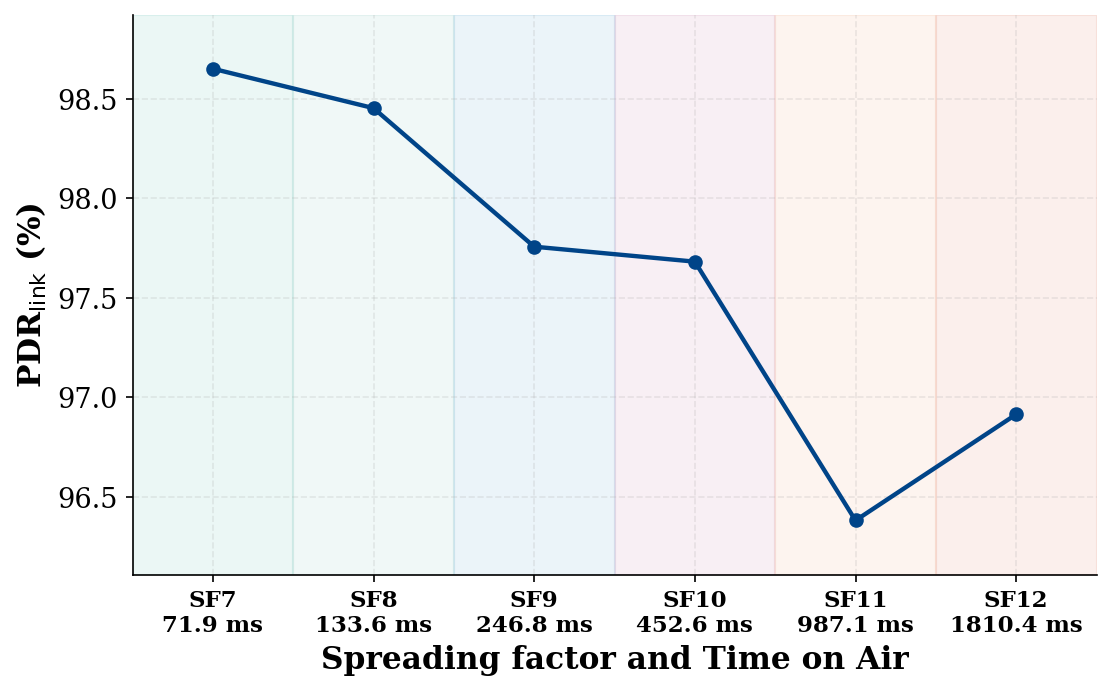

In [17]:
# Fig 05-03-g — PDR by exact spreading factor (E7)
sfs = np.arange(7, 13)
sf_pdr_values = [pdr_grp(df_link.loc[df_link['e7_sf'].eq(sf)]) for sf in sfs]
sf_colors = [
    C['green'], C['teal'], C['blue'],
    C['purple'], C['orange'], C['red'],
]

fig, ax = event_panel()
for sf, shade_color in zip(sfs, sf_colors):
    ax.axvspan(sf - 0.5, sf + 0.5, color=shade_color, alpha=0.08, zorder=0)

ax.plot(
    sfs,
    sf_pdr_values,
    'o-',
    color=C['navy'],
    linewidth=2.1,
    markersize=6,
    zorder=3,
)
ax.set_xticks(sfs)
ax.set_xticklabels(
    [f'SF{sf}\n{TOA_MS[sf]:.1f} ms' for sf in sfs],
    fontsize=11,
    fontweight='bold',
)
ax.set_xlim(6.5, 12.5)
ax.set_xlabel('Spreading factor and Time on Air', fontsize=LABEL_FONTSIZE, fontweight='bold')
ax.set_ylabel(PDR_LABEL, fontsize=LABEL_FONTSIZE, fontweight='bold')
ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)
ax.margins(y=0.12)

fig.tight_layout()
save_fig(fig, '05_03_g_sf_pdr')


## 9 · Effective Signal Power

**Event E8** tests the locked poor, moderate, and strong ESP tiers. The continuous profile shows whether link PDR follows the expected signal-quality ordering.


In [18]:
print('=' * 60)
print('SIGNAL CONTEXT EVENT (E8)')
print('=' * 60)

signal_results = {}

# E8: ESP tier — 3 analytical tiers
print('E8: PDR by ESP Tier (poor / moderate / strong)')
for tier in ['poor', 'moderate', 'strong']:
    g = df_link[df_link['e8_esp_tier'] == tier]
    if len(g) > 0:
        rx = len(g)
        lost = int(g['tx_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<12}: {pdr:.2f}%  (n={rx:,})')

r = pdr_compare(df_link, 'e8_esp_tier', 'poor', 'strong')
print()
print_comparison(r, 'Poor ESP vs Strong ESP')
signal_results['E8_poor_vs_strong'] = r

SIGNAL CONTEXT EVENT (E8)
E8: PDR by ESP Tier (poor / moderate / strong)
    poor        : 96.63%  (n=98,423)
    moderate    : 97.12%  (n=247,848)
    strong      : 97.96%  (n=2,288,183)

Poor ESP vs Strong ESP
                  poor  96.63%  n=98,423
                strong  97.96%  n=2,288,183
  Difference             -1.33 pp
  95% block-bootstrap CI [-1.61, -1.06] pp
  Inference              lower PDR, statistically supported
  Bootstrap              10,000 samples of 350 synchronized 1-day blocks



Saved ..\figures\3\05_03_h_signal_context_pdr.png


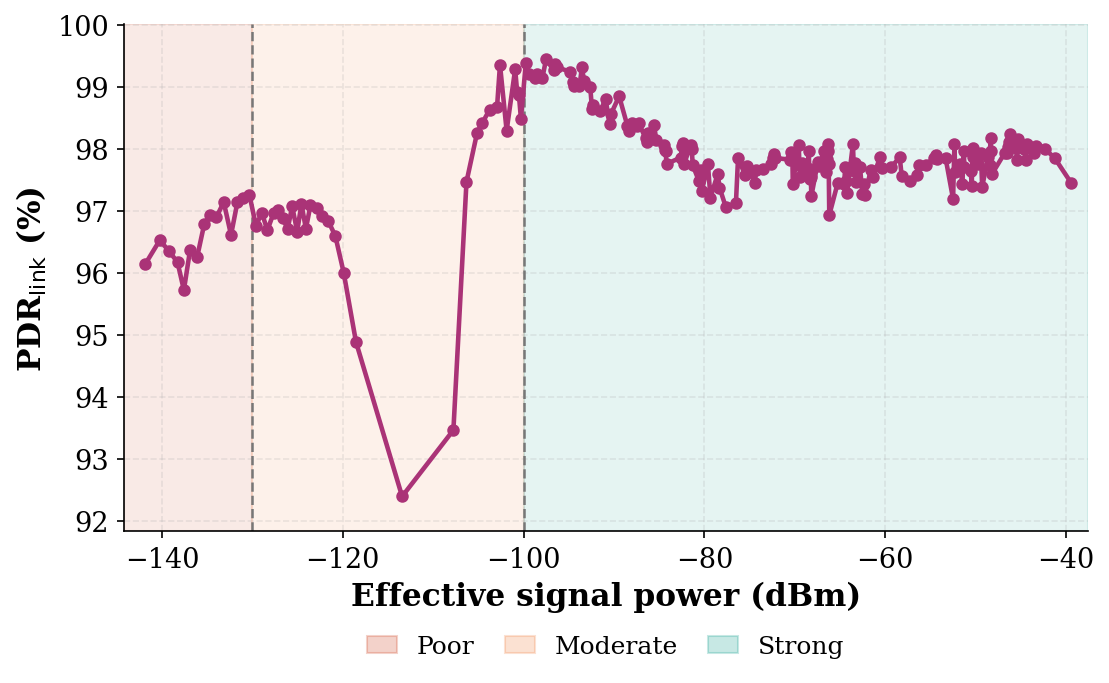

In [19]:
# Fig 05-03-h — ESP profile (E8)
fig, ax = event_panel()
e8_profile = pdr_profile(
    ax,
    df_link,
    'esp',
    boundaries=[-130, -100],
    tier_colors=[C['red'], C['orange'], C['green']],
    tier_labels=['Poor', 'Moderate', 'Strong'],
    xlabel='Effective signal power (dBm)',
    color=C['purple'],
)

fig.tight_layout()
save_fig(fig, '05_03_h_signal_context_pdr')


## 10 · Combined Event Comparison and Bootstrap Inference

The eight locked contrasts are placed on one ΔPDR scale. Their synchronized 1-day block-bootstrap intervals provide the common inferential comparison for RQ2.

The RQ2 confidence interval is not used as an automatic predictor-selection rule. RQ3 eligibility is evaluated separately because a predictor can have a supported marginal contrast yet remain unsuitable for multivariable burst modeling.


In [20]:
print('=' * 72)
print('ALL EVENTS  PDR SUMMARY WITH 1-DAY BLOCK-BOOTSTRAP 95% CI (PRIMARY DESIGN)')
print('=' * 72)

EVENT_SPECS = [
    ('E1', 'e1_co2_tier', 'high', 'background', 'High CO2 versus background'),
    ('E2', 'e2_co2_transition', 1, 0, 'Rapid CO2 transition versus stable'),
    ('E3', 'e3_office_hours', 1, 0, 'Office hours versus off-hours'),
    ('E4', 'e4_pm25_tier', 'elevated', 'clean', 'Elevated versus clean PM2.5'),
    ('E5', 'e5_temp_tier', 'warm', 'cool', 'Warm versus cool'),
    ('E6', 'e6_humidity_tier', 'humid', 'dry', 'Humid versus dry'),
    ('E7', 'e7_sf', 12, 7, 'SF12 versus SF7'),
    ('E8', 'e8_esp_tier', 'poor', 'strong', 'Poor versus strong ESP'),
]

EVENT_COLUMN = {
    event_id: column
    for event_id, column, _, _, _ in EVENT_SPECS
}

EVENT_LEVELS = {
    'E1': ['background', 'moderate', 'high'],
    'E2': [0, 1],
    'E3': [0, 1],
    'E4': ['clean', 'moderate', 'elevated'],
    'E5': ['cool', 'moderate', 'warm'],
    'E6': ['dry', 'normal', 'humid'],
    'E7': [7, 8, 9, 10, 11, 12],
    'E8': ['strong', 'moderate', 'poor'],
}

all_results = []
for event_id, column, active, reference, label in EVENT_SPECS:
    result = pdr_compare(df_link, column, active, reference)
    all_results.append(
        {
            'Event': event_id,
            'Comparison': label,
            'PDR_active': result['pdr1'],
            'PDR_reference': result['pdr0'],
            'Diff_pp': result['diff_pp'],
            'CI_low_pp': result['ci_low_pp'],
            'CI_high_pp': result['ci_high_pp'],
            'Supported': result['statistically_supported'],
            'Block_days': result['block_days'],
            'Bootstrap_samples': result['n_boot'],
        }
    )

results_df = pd.DataFrame(all_results)
plot_df = results_df.sort_values('Diff_pp').reset_index(drop=True)

print(
    f'{"Event":<6} {"Comparison":<38} {"PDR active":>11} '
    f'{"PDR reference":>14} {"Diff":>9} {"95% CI":>21} {"Supported":>11}'
)
print('-' * 120)
for _, row in results_df.iterrows():
    ci = f'[{row["CI_low_pp"]:+.2f}, {row["CI_high_pp"]:+.2f}]'
    support = 'Yes' if row['Supported'] else 'No'
    print(
        f'{row["Event"]:<6} {row["Comparison"]:<38} '
        f'{row["PDR_active"]:>10.2f}% {row["PDR_reference"]:>13.2f}% '
        f'{row["Diff_pp"]:>+8.2f} {ci:>21} {support:>11}'
    )

SUPPORTED_EVENTS = results_df.loc[results_df['Supported'], 'Event'].tolist()
INCONCLUSIVE_EVENTS = results_df.loc[~results_df['Supported'], 'Event'].tolist()

print()
print('=' * 72)
print('RQ2 INFERENCE')
print('=' * 72)
print(f'Supported contrasts     {", ".join(SUPPORTED_EVENTS)}')
print(f'Inconclusive contrasts  {", ".join(INCONCLUSIVE_EVENTS)}')

# RQ3 uses a separate estimability check. Each predictor must be defined
# for every modeled interval and every modeled level must contain at least
# ten burst outcomes.
MIN_BURST_OUTCOMES_PER_LEVEL = 10
adequacy_rows = []
for event_id, column in EVENT_COLUMN.items():
    missing_rows = int(df_link[column].isna().sum())
    level_rows = []
    for level in EVENT_LEVELS[event_id]:
        group = df_link.loc[df_link[column].eq(level), 'tx_loss']
        level_rows.append(
            {
                'Event': event_id,
                'Level': level,
                'Intervals': int(len(group)),
                'Loss_occurrences': int(group.gt(0).sum()),
                'Burst_occurrences': int(group.ge(3).sum()),
                'Missing_predictor_rows': missing_rows,
            }
        )
    adequacy_rows.extend(level_rows)

adequacy_df = pd.DataFrame(adequacy_rows)
event_adequacy = (
    adequacy_df.groupby('Event', sort=False)
    .agg(
        Minimum_bursts_per_level=('Burst_occurrences', 'min'),
        Missing_predictor_rows=('Missing_predictor_rows', 'max'),
    )
    .reset_index()
)
event_adequacy['Model_eligible'] = (
    event_adequacy['Minimum_bursts_per_level']
    .ge(MIN_BURST_OUTCOMES_PER_LEVEL)
    & event_adequacy['Missing_predictor_rows'].eq(0)
)

MODEL_EVENTS = event_adequacy.loc[
    event_adequacy['Model_eligible'], 'Event'
].tolist()
MODEL_EXCLUDED_EVENTS = event_adequacy.loc[
    ~event_adequacy['Model_eligible'], 'Event'
].tolist()

results_df['Model_included'] = results_df['Event'].isin(MODEL_EVENTS)

print()
print('=' * 72)
print('RQ3 DATA-ADEQUACY CHECK')
print('=' * 72)
print(event_adequacy.to_string(index=False))
print(f'Eligible events          {", ".join(MODEL_EVENTS)}')
print(f'Not modeled              {", ".join(MODEL_EXCLUDED_EVENTS)}')

EXPECTED_MODEL_EVENTS = ['E1', 'E3', 'E4', 'E5', 'E7', 'E8']
if MODEL_EVENTS != EXPECTED_MODEL_EVENTS:
    print(
        f'NOTE: eligible-event set is {MODEL_EVENTS}, which differs from '
        f'the previously observed {EXPECTED_MODEL_EVENTS}. This can '
        'legitimately happen under a different bootstrap block length or '
        'a revised dataset. Re-check the RQ2/RQ3 thesis text against this '
        'run before finalising numbers -- do not assume the old event set.'
    )
else:
    print(
        'RQ3 design matches the previously observed six-event set '
        '(E1, E3, E4, E5, E7, E8).'
    )


ALL EVENTS  PDR SUMMARY WITH 1-DAY BLOCK-BOOTSTRAP 95% CI (PRIMARY DESIGN)
Event  Comparison                              PDR active  PDR reference      Diff                95% CI   Supported
------------------------------------------------------------------------------------------------------------------------
E1     High CO2 versus background                  95.07%         98.32%    -3.25        [-3.90, -2.62]         Yes
E2     Rapid CO2 transition versus stable          97.76%         99.02%    -1.26        [-1.63, -0.90]         Yes
E3     Office hours versus off-hours               97.03%         98.17%    -1.13        [-1.44, -0.84]         Yes
E4     Elevated versus clean PM2.5                 78.09%         98.10%   -20.01      [-27.90, -15.25]         Yes
E5     Warm versus cool                            98.21%         97.30%    +0.91        [+0.49, +1.32]         Yes
E6     Humid versus dry                            94.70%         96.90%    -2.20        [-5.01, +3.33]    

## 10b · Block-Length Sensitivity Analysis

The primary seven-day result is compared with three-day and fourteen-day blocks to test whether the RQ2 support decision depends on block length. This sensitivity check does not replace the separate RQ3 data-adequacy rule.


In [21]:
print('=' * 130)
print('BLOCK-LENGTH SENSITIVITY  —  1-DAY (PRIMARY) VS 3-DAY, 7-DAY, 14-DAY')
print('=' * 130)
header = f'{"Event":<6} {"1-day (primary)":>23} {"Supp":>6}'
for d in SENSITIVITY_BLOCK_DAYS:
    header += f'  {f"{d}-day":>21} {"Supp":>6}'
header += f'  {"Stable":>7}'
print(header)
print('-' * 130)

sensitivity_results = []
for event_id, column, active, reference, label in EVENT_SPECS:
    primary_row = results_df.loc[results_df['Event'].eq(event_id)].iloc[0]
    row_out = {
        'Event': event_id,
        'Diff_pp': primary_row['Diff_pp'],
        'CI_low_1d': primary_row['CI_low_pp'],
        'CI_high_1d': primary_row['CI_high_pp'],
        'Supported_1d': bool(primary_row['Supported']),
    }
    support_flags = [bool(primary_row['Supported'])]
    line = f'{event_id:<6} [{primary_row["CI_low_pp"]:+.2f}, {primary_row["CI_high_pp"]:+.2f}]'.ljust(31)
    line += f'{"Yes" if primary_row["Supported"] else "No":>6}'

    for d in SENSITIVITY_BLOCK_DAYS:
        r = pdr_compare(df_link, column, active, reference, block_days=d)
        row_out[f'CI_low_{d}d'] = r['ci_low_pp']
        row_out[f'CI_high_{d}d'] = r['ci_high_pp']
        row_out[f'Supported_{d}d'] = r['statistically_supported']
        support_flags.append(r['statistically_supported'])
        ci_str = f'[{r["ci_low_pp"]:+.2f}, {r["ci_high_pp"]:+.2f}]'
        line += f'  {ci_str:>21}{"Yes" if r["statistically_supported"] else "No":>6}'

    stable = len(set(support_flags)) == 1
    row_out['Stable'] = stable
    sensitivity_results.append(row_out)
    line += f'  {"Yes" if stable else "Flag":>7}'
    print(line)

sensitivity_df = pd.DataFrame(sensitivity_results)
print(
    f'\nStable support decision (same conclusion at every block length) for '
    f'{int(sensitivity_df["Stable"].sum())} of {len(sensitivity_df)} contrasts.'
)
print(
    'Any event flagged unstable here should be reported as block-length-'
    'dependent in the thesis text rather than as a single fixed verdict.'
)


BLOCK-LENGTH SENSITIVITY  —  1-DAY (PRIMARY) VS 3-DAY, 7-DAY, 14-DAY
Event          1-day (primary)   Supp                  3-day   Supp                  7-day   Supp                 14-day   Supp   Stable
----------------------------------------------------------------------------------------------------------------------------------
E1     [-3.90, -2.62]             Yes         [-3.98, -2.52]   Yes         [-4.14, -2.36]   Yes         [-4.22, -2.19]   Yes      Yes
E2     [-1.63, -0.90]             Yes         [-1.67, -0.85]   Yes         [-1.68, -0.85]   Yes         [-1.67, -0.84]   Yes      Yes
E3     [-1.44, -0.84]             Yes         [-1.44, -0.83]   Yes         [-1.54, -0.78]   Yes         [-1.57, -0.75]   Yes      Yes
E4     [-27.90, -15.25]           Yes       [-30.23, -14.43]   Yes       [-31.27, -16.07]   Yes       [-35.95, -16.28]   Yes      Yes
E5     [+0.49, +1.32]             Yes         [+0.33, +1.48]   Yes         [+0.17, +1.63]   Yes         [-0.07, +1.84]    No   

Saved ..\figures\3\05_03_i1_pdr_difference_per_event.png


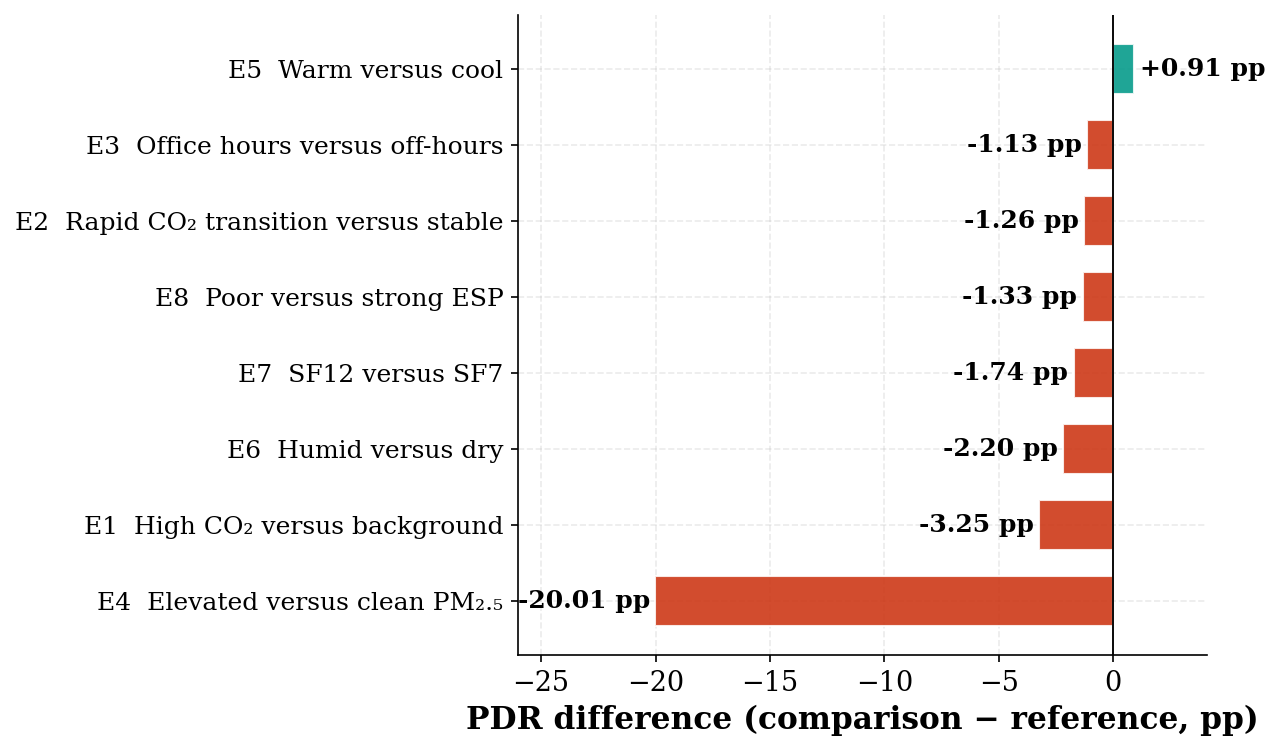

In [22]:
# Fig 05-03-i1 — PDR difference per event
event_labels = {
    'E1': 'E1  High CO₂ versus background',
    'E2': 'E2  Rapid CO₂ transition versus stable',
    'E3': 'E3  Office hours versus off-hours',
    'E4': 'E4  Elevated versus clean PM₂.₅',
    'E5': 'E5  Warm versus cool',
    'E6': 'E6  Humid versus dry',
    'E7': 'E7  SF12 versus SF7',
    'E8': 'E8  Poor versus strong ESP',
}
plot_df = results_df.sort_values('Diff_pp').reset_index(drop=True)
plot_df['label'] = plot_df['Event'].map(event_labels)

fig1, ax1 = plt.subplots(figsize=(8.2, 5.2))
bar_colors = [
    C['red'] if value < 0 else C['green']
    for value in plot_df['Diff_pp']
]
bars = ax1.barh(
    plot_df['label'],
    plot_df['Diff_pp'],
    color=bar_colors,
    alpha=0.88,
    edgecolor='white',
    height=0.66,
)
ax1.axvline(0, color='black', linewidth=0.9)

span = max(
    abs(float(plot_df['Diff_pp'].min())),
    abs(float(plot_df['Diff_pp'].max())),
    1.0,
)
text_offset = 0.012 * span
for bar, value in zip(bars, plot_df['Diff_pp']):
    ax1.text(
        value + (text_offset if value >= 0 else -text_offset),
        bar.get_y() + bar.get_height() / 2,
        f'{value:+.2f} pp',
        ha='left' if value >= 0 else 'right',
        va='center',
        fontsize=12,
        fontweight='bold',
    )

left = min(float(plot_df['Diff_pp'].min()), 0.0) - 0.30 * span
right = max(float(plot_df['Diff_pp'].max()), 0.0) + 0.16 * span
ax1.set_xlim(left, right)
ax1.set_xlabel(
    'PDR difference (comparison − reference, pp)',
    fontsize=LABEL_FONTSIZE,
    fontweight='bold',
)
ax1.tick_params(axis='x', labelsize=TICK_FONTSIZE)
ax1.tick_params(axis='y', labelsize=12)

fig1.tight_layout()
fig1.subplots_adjust(left=0.39)
save_fig(fig1, '05_03_i1_pdr_difference_per_event')


Saved ..\figures\3\05_03_i2_event_block_bootstrap_confidence_intervals.png


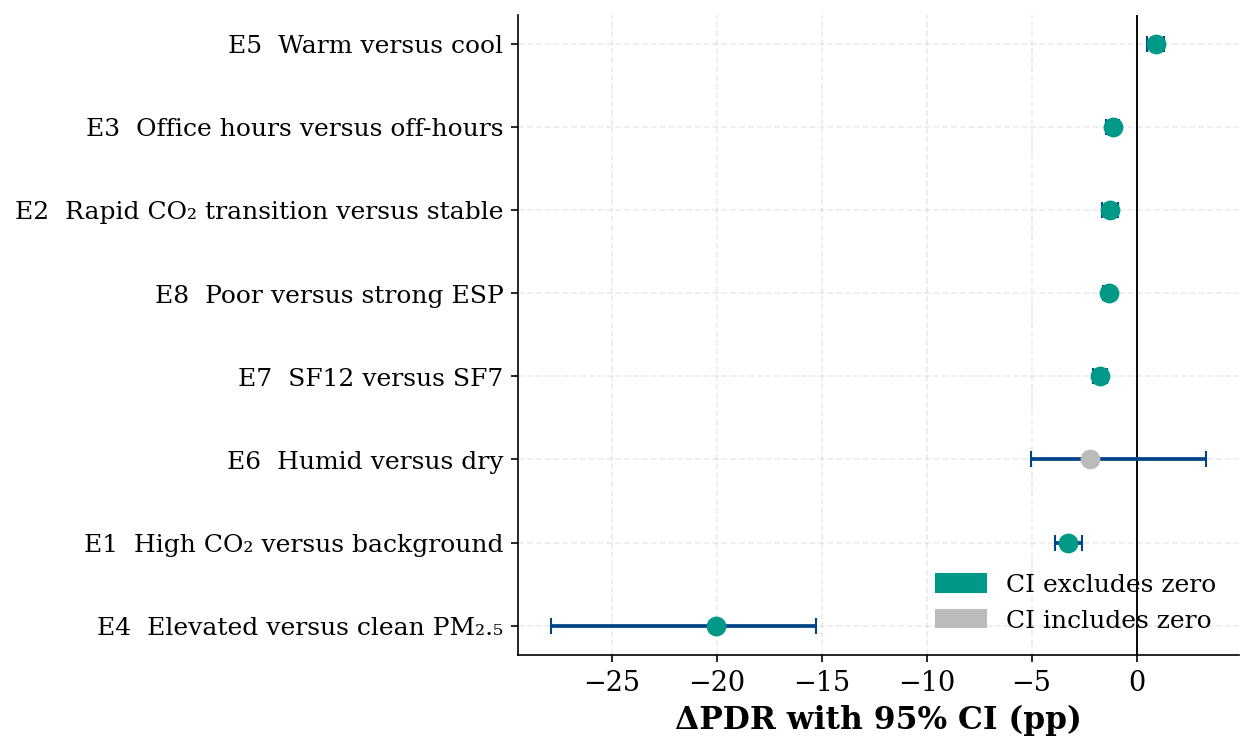

In [23]:
# Fig 05-03-i2 — Block-bootstrap confidence intervals per event
fig2, ax2 = plt.subplots(figsize=(8.2, 5.2))
y_pos = np.arange(len(plot_df))
err_low = (plot_df['Diff_pp'] - plot_df['CI_low_pp']).clip(lower=0)
err_high = (plot_df['CI_high_pp'] - plot_df['Diff_pp']).clip(lower=0)

ax2.errorbar(
    plot_df['Diff_pp'],
    y_pos,
    xerr=[err_low, err_high],
    fmt='none',
    capsize=4,
    elinewidth=1.8,
    ecolor=C['navy'],
    zorder=3,
)

point_colors = [
    C['green'] if supported else C['grey']
    for supported in plot_df['Supported']
]
for y_value, delta, point_color in zip(
    y_pos, plot_df['Diff_pp'], point_colors
):
    ax2.plot(
        delta,
        y_value,
        marker='o',
        markersize=8.5,
        color=point_color,
        linestyle='none',
        zorder=5,
    )

ax2.axvline(0, color='black', linewidth=0.9)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(plot_df['label'], fontsize=12)
ax2.set_xlabel(
    'ΔPDR with 95% CI (pp)',
    fontsize=LABEL_FONTSIZE,
    fontweight='bold',
)
ax2.tick_params(axis='x', labelsize=TICK_FONTSIZE)
ax2.legend(
    handles=[
        mpatches.Patch(
            color=C['green'],
            label='CI excludes zero',
        ),
        mpatches.Patch(
            color=C['grey'],
            label='CI includes zero',
        ),
    ],
    fontsize=LEGEND_FONTSIZE,
    loc='lower right',
    frameon=False,
)

fig2.tight_layout()
fig2.subplots_adjust(left=0.39)
save_fig(fig2, '05_03_i2_event_block_bootstrap_confidence_intervals')


## 11 · Logistic Regression for Loss Occurrence

**RQ3 outcome** `1[tx_loss > 0]`

The design matrix uses the events that pass the common RQ3 data-adequacy rule and device fixed effects with ED0 as the reference. In this dataset, E2 is not defined for intervals longer than three minutes and has only one burst outcome in its rapid-transition level. E6 has only three burst outcomes in the humid level. Both fail the common eligibility rule, leaving E1, E3, E4, E5, E7, and E8 for both models.

The categorical reference conditions are background CO₂, off-hours, clean PM₂.₅, cool temperature, strong ESP, and ED0. The E7 coefficient represents a one-step increase in spreading factor.


In [24]:
from scipy.special import expit

LR_BOOTSTRAP_REPS = 1000
LR_BLOCK_DAYS = PRIMARY_BLOCK_DAYS
LR_RANDOM_STATE = 42

FEATURE_SPECS = {
    'E1': {
        'kind': 'categorical',
        'column': 'e1_co2_tier',
        'levels': ['background', 'moderate', 'high'],
    },
    'E2': {
        'kind': 'binary',
        'column': 'e2_co2_transition',
        'levels': [0, 1],
    },
    'E3': {
        'kind': 'binary',
        'column': 'e3_office_hours',
        'levels': [0, 1],
    },
    'E4': {
        'kind': 'categorical',
        'column': 'e4_pm25_tier',
        'levels': ['clean', 'moderate', 'elevated'],
    },
    'E5': {
        'kind': 'categorical',
        'column': 'e5_temp_tier',
        'levels': ['cool', 'moderate', 'warm'],
    },
    'E6': {
        'kind': 'categorical',
        'column': 'e6_humidity_tier',
        'levels': ['dry', 'normal', 'humid'],
    },
    'E7': {
        'kind': 'numeric',
        'column': 'e7_sf',
        'levels': [7, 8, 9, 10, 11, 12],
    },
    'E8': {
        'kind': 'categorical',
        'column': 'e8_esp_tier',
        'levels': ['strong', 'moderate', 'poor'],
    },
}

model_columns = [FEATURE_SPECS[event]['column'] for event in MODEL_EVENTS]
model_columns += ['device_id', 'time', 'tx_loss']
model_df = df_link.dropna(subset=model_columns).copy()

excluded_incomplete = len(df_link) - len(model_df)
print(f'Modeled events           {", ".join(MODEL_EVENTS)}')
print(f'Data-adequacy exclusions {", ".join(MODEL_EXCLUDED_EVENTS)}')
print(f'Complete model rows      {len(model_df):,}')
print(f'Incomplete rows excluded {excluded_incomplete:,}')

feature_parts = []
for event in MODEL_EVENTS:
    spec = FEATURE_SPECS[event]
    column = spec['column']
    observed = set(pd.Series(model_df[column]).dropna().unique())
    expected = set(spec['levels'])
    unexpected = observed - expected
    if unexpected:
        raise ValueError(
            f'Unexpected values in {column}: {sorted(unexpected)}'
        )

    if spec['kind'] == 'categorical':
        categorical = pd.Series(
            pd.Categorical(
                model_df[column],
                categories=spec['levels'],
                ordered=True,
            ),
            index=model_df.index,
            name=column,
        )
        dummies = pd.get_dummies(
            categorical,
            prefix=column,
            drop_first=True,
            dtype=float,
        )
        feature_parts.append(dummies)
    else:
        feature_parts.append(
            pd.DataFrame(
                {
                    column: pd.to_numeric(
                        model_df[column], errors='raise'
                    ).astype(float)
                },
                index=model_df.index,
            )
        )

device = pd.Series(
    pd.Categorical(
        model_df['device_id'],
        categories=EXPECTED_DEVICES,
        ordered=True,
    ),
    index=model_df.index,
    name='device_id',
)
device_dummies = pd.get_dummies(
    device,
    prefix='device_id',
    drop_first=True,
    dtype=float,
)
feature_parts.append(device_dummies)

feature_df = pd.concat(feature_parts, axis=1)
if feature_df.isna().any().any():
    raise ValueError('The RQ3 design matrix contains missing values.')

X = feature_df.to_numpy(dtype=float)
feat_names = feature_df.columns.tolist()
y = pd.to_numeric(model_df['tx_loss'], errors='coerce').gt(0).to_numpy(dtype=int)

campaign_start = model_df['time'].min().floor('D')
lr_block_id = (
    (
        (model_df['time'] - campaign_start).dt.total_seconds()
        // (LR_BLOCK_DAYS * 24 * 60 * 60)
    )
    .astype(int)
    .to_numpy()
)


def prepare_block_pattern_design(X, groups):
    """Aggregate identical predictor patterns within synchronized blocks."""
    patterns, pattern_id = np.unique(X, axis=0, return_inverse=True)
    block_values, block_id = np.unique(groups, return_inverse=True)
    n_blocks = len(block_values)
    n_patterns = len(patterns)
    flat_id = block_id * n_patterns + pattern_id
    trials = np.bincount(
        flat_id,
        minlength=n_blocks * n_patterns,
    ).reshape(n_blocks, n_patterns).astype(float)
    design = np.column_stack([np.ones(n_patterns), patterns])
    return {
        'design': design,
        'patterns': patterns,
        'pattern_id': pattern_id,
        'block_id': block_id,
        'flat_id': flat_id,
        'trials_by_block': trials,
        'n_blocks': n_blocks,
        'n_patterns': n_patterns,
    }


def _aggregate_successes(block_design, y):
    return np.bincount(
        block_design['flat_id'],
        weights=y,
        minlength=(
            block_design['n_blocks']
            * block_design['n_patterns']
        ),
    ).reshape(
        block_design['n_blocks'],
        block_design['n_patterns'],
    )


def _binomial_log_likelihood(design, trials, successes, beta):
    eta = np.clip(design @ beta, -35.0, 35.0)
    return float(
        np.sum(successes * eta - trials * np.logaddexp(0.0, eta))
    )


def _fit_aggregated_logit(
    design,
    trials,
    successes,
    initial=None,
    tolerance=1e-8,
    max_iter=100,
):
    """Unpenalized binomial MLE by Newton iteration on grouped counts."""
    keep = trials > 0
    x = design[keep]
    n = trials[keep]
    s = successes[keep]
    beta = (
        np.zeros(x.shape[1], dtype=float)
        if initial is None
        else np.asarray(initial, dtype=float).copy()
    )
    old_ll = _binomial_log_likelihood(x, n, s, beta)

    for _ in range(max_iter):
        eta = np.clip(x @ beta, -35.0, 35.0)
        probability = expit(eta)
        weight = np.maximum(n * probability * (1.0 - probability), 1e-10)
        gradient = x.T @ (s - n * probability)
        information = x.T @ (weight[:, None] * x)

        # A negligible diagonal stabilizer is used only to solve a nearly
        # singular information matrix. It does not impose substantive
        # coefficient shrinkage.
        stabilizer = np.eye(len(beta)) * 1e-10
        stabilizer[0, 0] = 0.0
        try:
            step = np.linalg.solve(information + stabilizer, gradient)
        except np.linalg.LinAlgError:
            step = np.linalg.lstsq(
                information + stabilizer,
                gradient,
                rcond=None,
            )[0]

        scale = 1.0
        while scale > 1e-6:
            candidate = beta + scale * step
            candidate_ll = _binomial_log_likelihood(x, n, s, candidate)
            if candidate_ll >= old_ll - 1e-8:
                break
            scale *= 0.5

        beta = candidate
        old_ll = candidate_ll
        if np.max(np.abs(scale * step)) < tolerance:
            return beta

    raise RuntimeError('The grouped logistic fit did not converge.')


def fit_lr_block_bootstrap(
    block_design,
    y,
    feat_names,
    n_boot=LR_BOOTSTRAP_REPS,
    random_state=LR_RANDOM_STATE,
):
    successes_by_block = _aggregate_successes(block_design, y)
    trials_observed = block_design['trials_by_block'].sum(axis=0)
    successes_observed = successes_by_block.sum(axis=0)
    beta_observed = _fit_aggregated_logit(
        block_design['design'],
        trials_observed,
        successes_observed,
    )
    odds_ratios = np.exp(beta_observed[1:])

    rng = np.random.default_rng(random_state)
    bootstrap_coefficients = []
    n_blocks = block_design['n_blocks']
    for replicate in range(n_boot):
        sampled_blocks = rng.integers(0, n_blocks, size=n_blocks)
        multiplicity = np.bincount(
            sampled_blocks,
            minlength=n_blocks,
        ).astype(float)
        trials = multiplicity @ block_design['trials_by_block']
        successes = multiplicity @ successes_by_block

        try:
            beta = _fit_aggregated_logit(
                block_design['design'],
                trials,
                successes,
                initial=beta_observed,
            )
        except RuntimeError:
            continue
        bootstrap_coefficients.append(beta[1:])

        if (replicate + 1) % 100 == 0 or replicate + 1 == n_boot:
            print(f'Completed {replicate + 1:,} of {n_boot:,} block samples')

    bootstrap_coefficients = np.asarray(
        bootstrap_coefficients,
        dtype=float,
    )
    minimum_valid = int(np.ceil(0.90 * n_boot))
    if len(bootstrap_coefficients) < minimum_valid:
        raise RuntimeError(
            f'Only {len(bootstrap_coefficients):,} of {n_boot:,} '
            f'logistic bootstrap fits were valid. '
            f'At least {minimum_valid:,} were required.'
        )

    ci_low = np.exp(
        np.percentile(bootstrap_coefficients, 2.5, axis=0)
    )
    ci_high = np.exp(
        np.percentile(bootstrap_coefficients, 97.5, axis=0)
    )
    ci_df = pd.DataFrame(
        {
            'OR': odds_ratios,
            'CI_lo': ci_low,
            'CI_hi': ci_high,
        },
        index=feat_names,
    )
    ci_df['Supported'] = (
        ci_df['CI_lo'].gt(1.0) | ci_df['CI_hi'].lt(1.0)
    )
    ordered_or = ci_df['OR'].sort_values(ascending=False)
    return ordered_or, ci_df


print('Aggregating repeated predictor patterns for exact grouped fitting.')
block_design = prepare_block_pattern_design(X, lr_block_id)
print(
    f'{len(model_df):,} intervals reduce to '
    f'{block_design["n_patterns"]:,} predictor patterns across '
    f'{block_design["n_blocks"]} observed synchronized blocks.'
)

print(
    f'Fitting loss-occurrence model with {LR_BOOTSTRAP_REPS:,} '
    f'synchronized {LR_BLOCK_DAYS}-day block samples'
)
odds_ratios, ci_loss = fit_lr_block_bootstrap(
    block_design,
    y,
    feat_names,
)

print(
    f'\n{"Predictor":<40} {"OR":>9} {"95% CI":>22} {"Inference":>24}'
)
print('-' * 99)
for section, selector in [
    ('EVENT PREDICTORS', lambda name: not name.startswith('device_id')),
    ('DEVICE FIXED EFFECTS RELATIVE TO ED0', lambda name: name.startswith('device_id')),
]:
    print(f'\n{section}')
    for feature, odds_ratio in odds_ratios.items():
        if not selector(feature):
            continue
        low = ci_loss.loc[feature, 'CI_lo']
        high = ci_loss.loc[feature, 'CI_hi']
        if low > 1.0:
            inference = 'higher adjusted odds'
        elif high < 1.0:
            inference = 'lower adjusted odds'
        else:
            inference = 'inconclusive'
        print(
            f'{feature:<40} {odds_ratio:>9.4f} '
            f'[{low:.3f}, {high:.3f}] {inference:>24}'
        )


Modeled events           E1, E3, E4, E5, E7, E8
Data-adequacy exclusions E2, E6
Complete model rows      2,634,454
Incomplete rows excluded 0
Aggregating repeated predictor patterns for exact grouped fitting.
2,634,454 intervals reduce to 3,293 predictor patterns across 350 observed synchronized blocks.
Fitting loss-occurrence model with 1,000 synchronized 1-day block samples
Completed 100 of 1,000 block samples
Completed 200 of 1,000 block samples
Completed 300 of 1,000 block samples
Completed 400 of 1,000 block samples
Completed 500 of 1,000 block samples
Completed 600 of 1,000 block samples
Completed 700 of 1,000 block samples
Completed 800 of 1,000 block samples
Completed 900 of 1,000 block samples
Completed 1,000 of 1,000 block samples

Predictor                                       OR                 95% CI                Inference
---------------------------------------------------------------------------------------------------

EVENT PREDICTORS
e4_pm25_tier_elevated          

In [25]:
# Shared predictor labels for both the loss-occurrence and burst-occurrence
# panels below (Fig 05-03-j).
plot_labels = {
    'e1_co2_tier_moderate': 'E1  Moderate CO₂',
    'e1_co2_tier_high': 'E1  High CO₂',
    'e3_office_hours': 'E3  Office hours',
    'e4_pm25_tier_moderate': 'E4  Moderate PM₂.₅',
    'e4_pm25_tier_elevated': 'E4  Elevated PM₂.₅',
    'e5_temp_tier_moderate': 'E5  Moderate temperature',
    'e5_temp_tier_warm': 'E5  Warm temperature',
    'e7_sf': 'E7  One-step SF increase',
    'e8_esp_tier_moderate': 'E8  Moderate ESP',
    'e8_esp_tier_poor': 'E8  Poor ESP',
}
print('Predictor labels ready for the merged loss/burst forest plot.')


Predictor labels ready for the merged loss/burst forest plot.


## 12 · Logistic Regression for Burst-Loss Occurrence

The second model uses the same eligible event predictors, reference conditions, device fixed effects, and synchronized one-day block-bootstrap procedure. Its binary outcome is `1[tx_loss >= 3]`.


In [26]:
print('=' * 72)
print('LOGISTIC REGRESSION FOR BURST-LOSS OCCURRENCE')
print('=' * 72)

y_burst = (
    pd.to_numeric(model_df['tx_loss'], errors='coerce')
    .ge(3)
    .to_numpy(dtype=int)
)

print(
    f'Fitting burst-occurrence model with {LR_BOOTSTRAP_REPS:,} '
    f'synchronized {LR_BLOCK_DAYS}-day block samples'
)
or_burst, ci_burst = fit_lr_block_bootstrap(
    block_design,
    y_burst,
    feat_names,
)

print(
    f'\n{"Predictor":<40} '
    f'{"OR loss":>10} {"95% CI loss":>22} '
    f'{"OR burst":>10} {"95% CI burst":>22}'
)
print('-' * 110)
for feature in odds_ratios.index:
    if feature.startswith('device_id'):
        continue
    print(
        f'{feature:<40} '
        f'{odds_ratios[feature]:>10.4f} '
        f'[{ci_loss.loc[feature, "CI_lo"]:.3f}, '
        f'{ci_loss.loc[feature, "CI_hi"]:.3f}] '
        f'{or_burst[feature]:>10.4f} '
        f'[{ci_burst.loc[feature, "CI_lo"]:.3f}, '
        f'{ci_burst.loc[feature, "CI_hi"]:.3f}]'
    )

print('\nDevice fixed effects remain in both models and are omitted above.')


LOGISTIC REGRESSION FOR BURST-LOSS OCCURRENCE
Fitting burst-occurrence model with 1,000 synchronized 1-day block samples
Completed 100 of 1,000 block samples
Completed 200 of 1,000 block samples
Completed 300 of 1,000 block samples
Completed 400 of 1,000 block samples
Completed 500 of 1,000 block samples
Completed 600 of 1,000 block samples
Completed 700 of 1,000 block samples
Completed 800 of 1,000 block samples
Completed 900 of 1,000 block samples
Completed 1,000 of 1,000 block samples

Predictor                                   OR loss            95% CI loss   OR burst           95% CI burst
--------------------------------------------------------------------------------------------------------------
e4_pm25_tier_elevated                       12.5164 [9.682, 15.090]    41.4125 [28.411, 63.098]
e4_pm25_tier_moderate                        2.7074 [2.345, 3.079]     3.2069 [2.141, 4.706]
e1_co2_tier_high                             2.3168 [2.039, 2.639]     3.1497 [2.239, 4.578]
e3_o

Saved ..\figures\3\05_03_j_loss_and_burst_forest.png


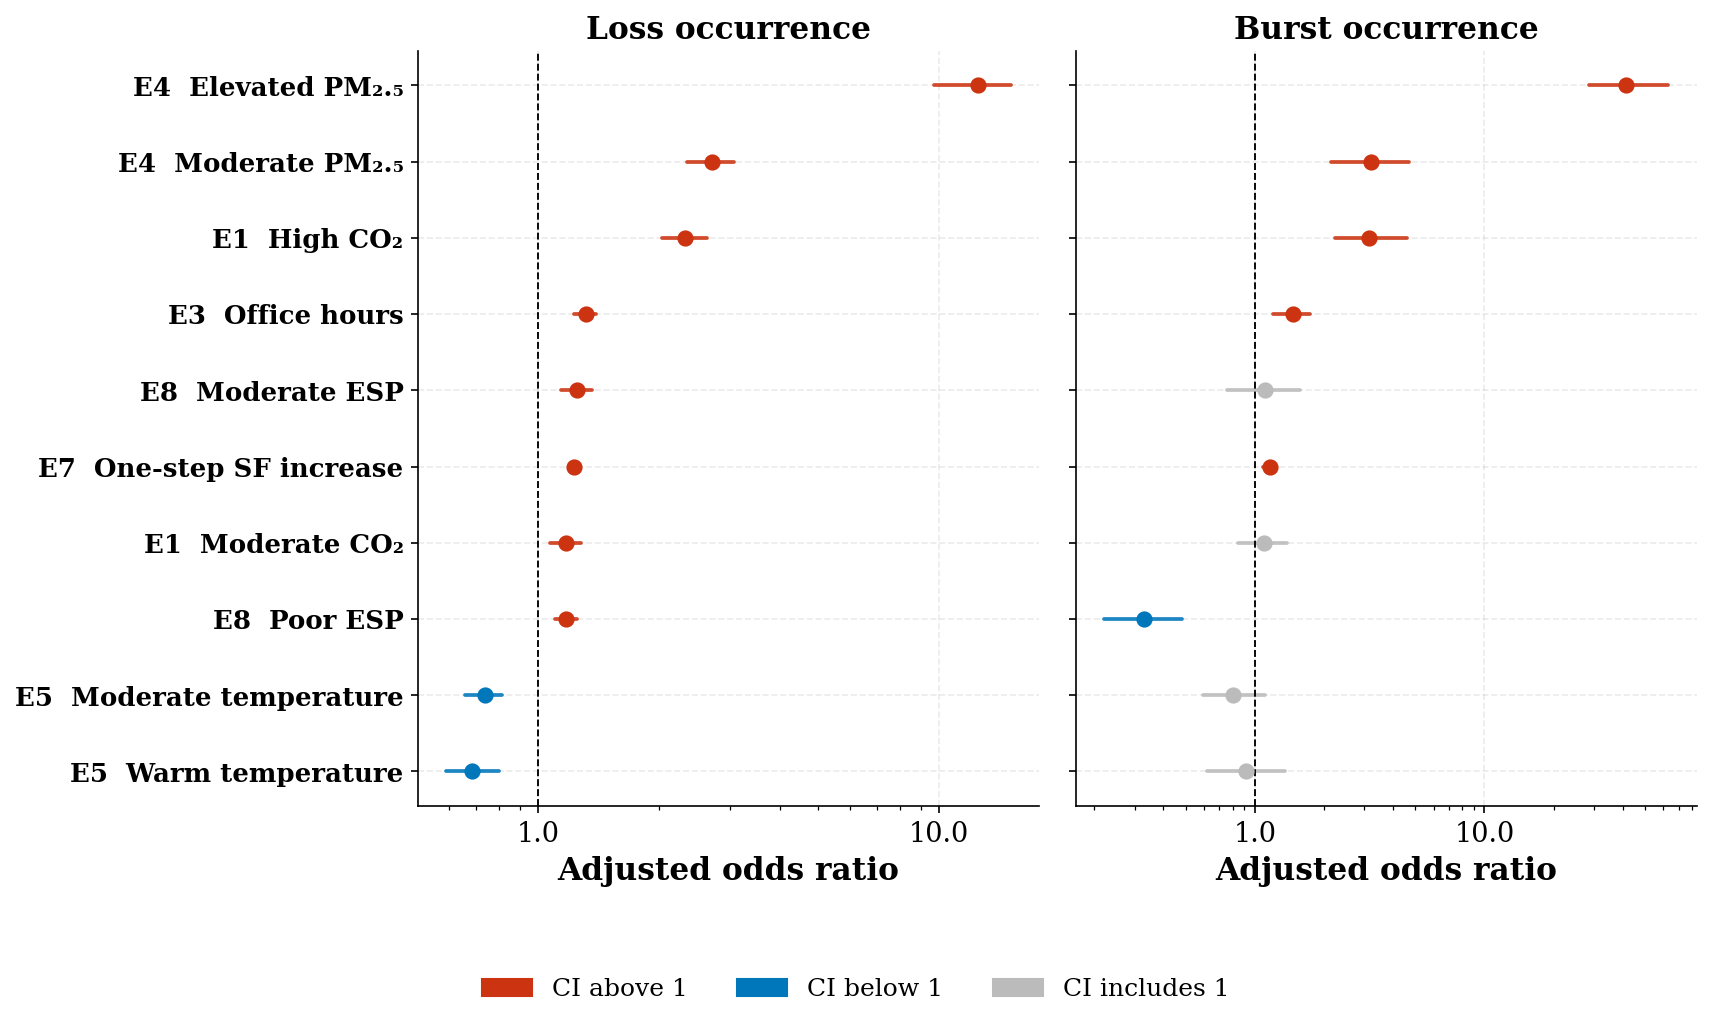

In [27]:
# Fig 05-03-j — Adjusted odds ratios: loss occurrence and burst occurrence
# Two panels sharing one row order and one legend. Each panel is coloured
# by ITS OWN confidence-interval direction (red = CI above 1, blue = CI
# below 1, grey = CI includes 1), so a predictor can show as supported in
# one outcome and inconclusive in the other -- that contrast is itself
# informative and would be lost by forcing a single fixed loss/burst colour
# pair onto both panels.
event_index_j = [f for f in ci_loss.index if not f.startswith('device_id')]

joint = pd.DataFrame({
    'OR_loss': odds_ratios.loc[event_index_j],
    'lo_loss': ci_loss.loc[event_index_j, 'CI_lo'],
    'hi_loss': ci_loss.loc[event_index_j, 'CI_hi'],
    'OR_burst': or_burst.loc[event_index_j],
    'lo_burst': ci_burst.loc[event_index_j, 'CI_lo'],
    'hi_burst': ci_burst.loc[event_index_j, 'CI_hi'],
})
joint['label'] = [plot_labels.get(f, f) for f in joint.index]
# order rows by loss OR so both panels share one interpretable row order
joint = joint.sort_values('OR_loss').reset_index(drop=True)

def _ci_color(lo, hi):
    if lo > 1.0:
        return C['red']
    if hi < 1.0:
        return C['blue']
    return C['grey']

fig, (ax_loss, ax_burst) = plt.subplots(
    1, 2, figsize=(11.6, len(joint) * 0.44 + 2.2), sharey=True
)

for i, row in joint.iterrows():
    c_loss = _ci_color(row['lo_loss'], row['hi_loss'])
    ax_loss.plot([row['lo_loss'], row['hi_loss']], [i, i],
                color=c_loss, linewidth=1.8, alpha=0.88, solid_capstyle='round')
    ax_loss.scatter(row['OR_loss'], i, color=c_loss, s=46, zorder=5)

    c_burst = _ci_color(row['lo_burst'], row['hi_burst'])
    ax_burst.plot([row['lo_burst'], row['hi_burst']], [i, i],
                 color=c_burst, linewidth=1.8, alpha=0.88, solid_capstyle='round')
    ax_burst.scatter(row['OR_burst'], i, color=c_burst, s=46, zorder=5)

for ax, title in [(ax_loss, 'Loss occurrence'), (ax_burst, 'Burst occurrence')]:
    ax.axvline(1.0, color='black', linewidth=0.9, linestyle='--')
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.set_xlabel('Adjusted odds ratio', fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_title(title, fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.tick_params(axis='x', labelsize=TICK_FONTSIZE)

ax_loss.set_yticks(range(len(joint)))
ax_loss.set_yticklabels(joint['label'], fontsize=12.5, fontweight='bold')

fig.legend(
    handles=[
        mpatches.Patch(color=C['red'], label='CI above 1'),
        mpatches.Patch(color=C['blue'], label='CI below 1'),
        mpatches.Patch(color=C['grey'], label='CI includes 1'),
    ],
    loc='upper center', bbox_to_anchor=(0.5, 0.02),
    ncol=3, frameon=False, fontsize=LEGEND_FONTSIZE,
)

fig.tight_layout(rect=[0, 0.06, 1, 1])
save_fig(fig, '05_03_j_loss_and_burst_forest')


## 13 · RQ2 and RQ3 Results Summary

This cell prints the event contrasts, the bootstrap selection decision, and the strongest adjusted associations without repeating the separate RQ1 analysis.


In [28]:
print('=' * 78)
print('RQ2 AND RQ3 RESULTS SUMMARY')
print('=' * 78)

ranked_events = results_df.reindex(
    results_df['Diff_pp'].abs().sort_values(ascending=False).index
)
print('\nRQ2  Event contrasts ranked by absolute PDR difference')
print(
    f'{"Event":<7} {"Comparison":<40} {"ΔPDR":>9} '
    f'{"95% CI":>21} {"RQ3":>10}'
)
print('-' * 92)
for _, row in ranked_events.iterrows():
    ci = f'[{row["CI_low_pp"]:+.2f}, {row["CI_high_pp"]:+.2f}]'
    model_status = 'Modeled' if row['Model_included'] else 'Not modeled'
    print(
        f'{row["Event"]:<7} {row["Comparison"]:<40} '
        f'{row["Diff_pp"]:>+8.2f} {ci:>21} {model_status:>10}'
    )

event_predictors = [
    feature
    for feature in odds_ratios.index
    if not feature.startswith('device_id') and feature in or_burst.index
]
strongest_predictors = sorted(
    event_predictors,
    key=lambda feature: max(
        abs(np.log(odds_ratios[feature])),
        abs(np.log(or_burst[feature])),
    ),
    reverse=True,
)[:6]

print('\nRQ3  Strongest adjusted event associations')
print(
    f'{"Predictor":<40} '
    f'{"OR loss":>10} {"95% CI loss":>22} '
    f'{"OR burst":>10} {"95% CI burst":>22}'
)
print('-' * 110)
for feature in strongest_predictors:
    print(
        f'{feature:<40} '
        f'{odds_ratios[feature]:>10.3f} '
        f'[{ci_loss.loc[feature, "CI_lo"]:.3f}, '
        f'{ci_loss.loc[feature, "CI_hi"]:.3f}] '
        f'{or_burst[feature]:>10.3f} '
        f'[{ci_burst.loc[feature, "CI_lo"]:.3f}, '
        f'{ci_burst.loc[feature, "CI_hi"]:.3f}]'
    )

print('\nDevice indicators were included as adjustment terms.')


RQ2 AND RQ3 RESULTS SUMMARY

RQ2  Event contrasts ranked by absolute PDR difference
Event   Comparison                                    ΔPDR                95% CI        RQ3
--------------------------------------------------------------------------------------------
E4      Elevated versus clean PM2.5                -20.01      [-27.90, -15.25]    Modeled
E1      High CO2 versus background                  -3.25        [-3.90, -2.62]    Modeled
E6      Humid versus dry                            -2.20        [-5.01, +3.33] Not modeled
E7      SF12 versus SF7                             -1.74        [-2.07, -1.41]    Modeled
E8      Poor versus strong ESP                      -1.33        [-1.61, -1.06]    Modeled
E2      Rapid CO2 transition versus stable          -1.26        [-1.63, -0.90] Not modeled
E3      Office hours versus off-hours               -1.13        [-1.44, -0.84]    Modeled
E5      Warm versus cool                            +0.91        [+0.49, +1.32]    Modeled



## 14 · Save Results


In [29]:
# Save the complete RQ2 event table
results_df.to_csv(DATA_DIR / '3_results.csv', index=False)
sensitivity_df.to_csv(
    DATA_DIR / '3_block_length_sensitivity.csv',
    index=False,
)

# Save adjusted odds ratios for both RQ3 outcomes
or_table = pd.DataFrame(
    {
        'predictor': odds_ratios.index,
        'OR_loss': odds_ratios.values,
        'loss_CI_lo': [
            ci_loss.loc[feature, 'CI_lo']
            for feature in odds_ratios.index
        ],
        'loss_CI_hi': [
            ci_loss.loc[feature, 'CI_hi']
            for feature in odds_ratios.index
        ],
        'OR_burst': [
            or_burst[feature]
            for feature in odds_ratios.index
        ],
        'burst_CI_lo': [
            ci_burst.loc[feature, 'CI_lo']
            for feature in odds_ratios.index
        ],
        'burst_CI_hi': [
            ci_burst.loc[feature, 'CI_hi']
            for feature in odds_ratios.index
        ],
    }
)
or_table.to_csv(DATA_DIR / '3_odds_ratios.csv', index=False)

print(f'Saved {DATA_DIR / "3_results.csv"}')
print(f'Saved {DATA_DIR / "3_block_length_sensitivity.csv"}')
print(f'Saved {DATA_DIR / "3_odds_ratios.csv"}')
print('\nNotebook 03 complete.')


Saved ..\data\3_results.csv
Saved ..\data\3_block_length_sensitivity.csv
Saved ..\data\3_odds_ratios.csv

Notebook 03 complete.


## 15 · Grouped Cross-Validation and Thesis Fill-In Sheet


In [30]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold


def grouped_block_auc(block_design, y, n_splits=5):
    """Grouped CV that keeps each synchronized seven-day block intact."""
    splitter = GroupKFold(n_splits=n_splits)
    block_index = np.arange(block_design['n_blocks'])
    successes_by_block = _aggregate_successes(block_design, y)
    auc_values = []

    for train_blocks, test_blocks in splitter.split(
        block_index,
        groups=block_index,
    ):
        train_trials = (
            block_design['trials_by_block'][train_blocks].sum(axis=0)
        )
        train_successes = successes_by_block[train_blocks].sum(axis=0)
        beta = _fit_aggregated_logit(
            block_design['design'],
            train_trials,
            train_successes,
        )

        test_mask = np.isin(block_design['block_id'], test_blocks)
        if np.unique(y[test_mask]).size < 2:
            continue
        probability_by_pattern = expit(block_design['design'] @ beta)
        probability = probability_by_pattern[
            block_design['pattern_id'][test_mask]
        ]
        auc_values.append(roc_auc_score(y[test_mask], probability))

    if not auc_values:
        raise RuntimeError('No valid grouped cross-validation folds were available.')
    return float(np.mean(auc_values)), float(np.std(auc_values, ddof=1))


auc_loss, auc_loss_sd = grouped_block_auc(block_design, y)
auc_burst, auc_burst_sd = grouped_block_auc(block_design, y_burst)

print(
    f'Loss model   1-day grouped 5-fold AUC '
    f'{auc_loss:.3f} ± {auc_loss_sd:.3f}'
)
print(
    f'Burst model  1-day grouped 5-fold AUC '
    f'{auc_burst:.3f} ± {auc_burst_sd:.3f}'
)

print('\n' + '=' * 78)
print('THESIS FILL-IN SHEET')
print('=' * 78)
print(f'RQ3 events       {", ".join(MODEL_EVENTS)}')
print(f'Not modeled      {", ".join(MODEL_EXCLUDED_EVENTS)}')
print(f'Loss AUC         {auc_loss:.3f}')
print(f'Burst AUC        {auc_burst:.3f}')
print(f'LR bootstrap     {LR_BOOTSTRAP_REPS:,} synchronized 1-day samples')
print('\nEvent predictors')
for feature in odds_ratios.index:
    if feature.startswith('device_id'):
        continue
    print(
        f'  {feature:<34} '
        f'loss {odds_ratios[feature]:>8.3f} '
        f'[{ci_loss.loc[feature, "CI_lo"]:.3f}, '
        f'{ci_loss.loc[feature, "CI_hi"]:.3f}]   '
        f'burst {or_burst[feature]:>8.3f} '
        f'[{ci_burst.loc[feature, "CI_lo"]:.3f}, '
        f'{ci_burst.loc[feature, "CI_hi"]:.3f}]'
    )


Loss model   1-day grouped 5-fold AUC 0.691 ± 0.012
Burst model  1-day grouped 5-fold AUC 0.718 ± 0.047

THESIS FILL-IN SHEET
RQ3 events       E1, E3, E4, E5, E7, E8
Not modeled      E2, E6
Loss AUC         0.691
Burst AUC        0.718
LR bootstrap     1,000 synchronized 1-day samples

Event predictors
  e4_pm25_tier_elevated              loss   12.516 [9.682, 15.090]   burst   41.413 [28.411, 63.098]
  e4_pm25_tier_moderate              loss    2.707 [2.345, 3.079]   burst    3.207 [2.141, 4.706]
  e1_co2_tier_high                   loss    2.317 [2.039, 2.639]   burst    3.150 [2.239, 4.578]
  e3_office_hours                    loss    1.313 [1.230, 1.394]   burst    1.466 [1.196, 1.741]
  e8_esp_tier_moderate               loss    1.249 [1.141, 1.359]   burst    1.105 [0.755, 1.571]
  e7_sf                              loss    1.232 [1.203, 1.260]   burst    1.161 [1.086, 1.239]
  e1_co2_tier_moderate               loss    1.172 [1.070, 1.280]   burst    1.093 [0.846, 1.384]
  e8_es